# Classification Problem: Portuguese Banking Marketing Dataset

# 1. Problem Context

This study used a dataset from marketing campaigns carried out by a Portuguese banking institution. The objective was to predict whether a customer would subscribe to a financial product called a **term deposit**, which is a fixed-income financial product.

The target variable of the study is:

- `y`: indicates whether the customer subscribed (`yes`) or did not subscribe (`no`) to the term deposit.

Therefore, this is a **binary classification** problem, in which the goal is to estimate the probability of subscription from each attempt to contact a customer and then apply a proper threshold to this probability to define it's a success or a failure.

---

## 1.1 Study Objective

The main objective of this study was to develop a Data Science pipeline, considering the following topics:

1. Exploratory data analysis;
2. Assessment of class imbalance;
3. Assessment of the relationship between explanatory variables and the target variable;
4. Feature selection;
5. Construction of predictive models (transformations were performed at this stage, only on the training set);
6. Comparison of the models with a simple baseline;
7. Threshold testing and hyperparameter optimization;
8. Calibration of predicted probabilities;
9. Evaluation of the models with metrics suitable for the problem;
10. Interpretation of the results;
11. Discussion of how the model could be used in production.

Rather than only predicting a final class, this study aimed to build a model capable of generating a **calibrated probability of subscription**, supporting business decisions with greater transparency and risk control.

---

## 1.2 Business Interpretation

In this problem, the positive class was defined as:

> Customer with probability of subscribing to the term deposit.

That is:

- `y = yes`: the customer subscribed to the product;
- `y = no`: the customer did not subscribe to the product.

The model can be used to support customer prioritization in marketing campaigns. Instead of treating all customers in the same way, the institution could use the model to identify customers with higher or lower probability of subscription and, based on that, define more efficient commercial strategies.

---

## 1.3 Handled Values

In the categorical variables `job`, `education`, `contact` and `poutcome`, there are records with the value `"unknown"`.

On one hand, these unknown values may be seen as a problem because they hide the true category of the record. For example, in `education`, an `"unknown"` value may actually correspond to one of the other values: `"primary"`, `"secondary"` or `"tertiary"`. In a real case, it would be interesting to try to fill in these values.

However, I believe it doesn't make sense to remove these values, because they may also contain predictive signal. In other words, an `"unknown"` record may carry information by itself. In the case of the variable `poutcome`, for example, these values mostly coincide (36,954 out of 36,959 records) with cases where the variable `previous` is equal to 0. That is, these customers had not been contacted before. This is information in itself, not noise.

Another point that required attention was the value `-1` in `pdays`. According to the data description on Kaggle, this represents records indicating that there was no previous contact with the customer. However, using this column directly in this form could introduce noise into the model. I considered it more appropriate to handle these values by creating the following columns:

- `was_previously_contacted`: indicates whether the customer had been contacted before (0 or 1);
- `pdays_since_previous_contact`: represents the number of days since the previous contact, assuming value 0 when the customer had never been contacted.

Therefore, the `pdays` column was not used for modeling.

---

## 1.4 Discussion of Classification Errors

As in any classification problem, there are two main types of error:

- False Positive

The model predicts that the customer will subscribe to the product, but in reality the customer does not subscribe.

In this context, this error can be risky if the company interprets that this customer already has a high chance of conversion and, because of that, stops directing appropriate commercial efforts toward that customer. Thus, a false positive may create a false sense of security and lead to the loss of a lead.

- False Negative

The model predicts that the customer will not subscribe to the product, but in reality the customer would subscribe.

In this case, the company may end up directing a campaign to a customer who already had a natural propensity to subscribe. This represents an operational and commercial cost, but it may be less severe than incorrectly assuming that a customer is practically already won.

Therefore, this study gave special attention to reducing **false positives**, prioritizing metrics that evaluate the quality of positive predictions, such as Precision, which is inversely related to the number of false positives.

Resampling methods (Oversampling, Undersampling, SMOTE, etc.) were not used because they distort the data distribution, which in turn distorts the probabilities calculated by the model. Instead, each model's own mechanisms were used to handle class imbalance, threshold evaluation and model calibration.

---

## 1.5 Evaluation Strategy

Since the dataset is imbalanced between customers who subscribed and customers who did not subscribe to the product, accuracy was not used as the main evaluation criterion.

In imbalanced datasets, a model can obtain high accuracy simply by always predicting the majority class, without actually learning useful patterns.

For this reason, more appropriate metrics were prioritized:

- **Precision** for the positive class;
- **Recall** for the positive class;
- **F0.5-score**, which is the [f-beta score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html) with a beta of 0.5, giving more weight to Precision than the F1-score;
- **PR-AUC**, more appropriate than ROC-AUC in imbalanced scenarios, especially when the positive class is the priority. Also, for probabilistic Machine Learning, a perfect ROC-AUC still doesn't mean a good model, since the model can be predicting probabilities such as 0.51 or 0.49 (assuming a threshold of 0.5) and these probabilities are hardly stable and trustworthy. A small change in the distribution of the data can mean a big change in the performance of the model;
- **Brier Score**, to evaluate probability quality;
- **Log Loss**, to evaluate penalties associated with incorrect probabilities;
- Probability calibration curves.

A simple baseline model was also built using `DummyClassifier`, to verify whether the trained models actually added value compared to a naive classifier.

---

## 1.6 Probabilistic Approach and Calibration

The final model was not treated only as a binary classifier. A probabilistic model was built to return:

1. The calibrated probability of subscription;
2. A final classification based on a selected threshold;
3. An uncertainty interval associated with the prediction.

To achieve this, probability calibration techniques were used, specifically the **Venn-Abers** method, which provides confidence intervals for each prediction and, consequently, estimates the risk associated with each prediction.

The width of the interval can be used as a measure of uncertainty.

For example:

`risk = upper_bound - lower_bound`

This approach is important because, in real applications, it's not enough to know whether the model classified a customer as `yes` or `no`. It is also necessary to understand the degree of confidence in the prediction in order to evaluate the associated prediction risk, enabling more solid business decisions.

---

## 1.7 Variable `duration`

The variable `duration` represents the duration of the last contact made with the customer. Although this variable has a strong relationship with the target variable, it is only known after the contact is made.

Based on the interpretation that the objective of the model is to support decisions before the commercial action, using this variable would create information leakage (*data leakage*). Therefore, the `duration` variable was removed from modeling.

---

## 1.8 Explainability

In addition to predictive performance, this study also aimed to explain the model results.

The following feature importance and explainability techniques were evaluated:

- Feature Importance;
- Calibrated Explanations, available at https://github.com/Moffran/calibrated_explanations

The objective was to understand which variables most influence the subscription prediction and to present the results in an interpretable way for decision-making.

---

## 1.9 Potential Production Usage

In a production scenario, the model could be used to classify a base of customers eligible for a marketing campaign.

For each customer, the pipeline would return:

- customer identifier(s);
- calibrated probability of subscription;
- prediction uncertainty interval;
- final predicted class;
- threshold used.

With this, the business could segment customers into groups such as:

- High probability of subscription and low risk;
- High probability of subscription and high risk;
- Low probability of subscription and low risk;
- Low probability of subscription and high risk.

This segmentation would support decisions about the marketing strategy that are better aligned with the cost of classification errors.

In section `2.7 MLOps`, I explained what would be necessary to use this model in production.


# 2 Study Code


## 2.1 Libraries Used


In [2]:

import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

# Statistics
from scipy.stats import chi2_contingency

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    brier_score_loss,
    log_loss,
    precision_recall_curve
)

# Machine Learning
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool

# Machine Learning - Hyperparameters
import optuna

# Machine Learning - Calibration
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibrationDisplay
from mapie.calibration import VennAbersCalibrator

# Machine Learning - Feature Importance
from calibrated_explanations import CalibratedExplainer

# Saving the model and other artifacts
import joblib

## 2.2 Data Loading and Initial Exploratory Analysis


In [3]:
df = pd.read_csv("bank-full.csv", sep=";")

In [4]:
display(df.head())
print(df.info())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None


In [5]:
df[df["poutcome"]=="unknown"][["pdays","previous","poutcome"]].value_counts()

pdays  previous  poutcome
-1     0         unknown     36954
 98    1         unknown         1
 168   5         unknown         1
 188   2         unknown         1
 416   2         unknown         1
 528   7         unknown         1
Name: count, dtype: int64

In [6]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

There are no null values in the dataset itself, but there are `"unknown"` values in several columns. In the `previous` column, based on my understanding of the data card on Kaggle, 0 means that there was no previous contact with this customer. The same applies to a value of -1 in `pdays`. As seen in the cells above, in `poutcome`, these cases were recorded as `"unknown"`. Even so, 5 of the 36,959 `"unknown"` records in `poutcome` do not coincide with records where there was no previous contact.


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"45,211.0000",40.9362,10.6188,18.0000,33.0000,39.0000,48.0000,95.0000
balance,"45,211.0000","1,362.2721","3,044.7658","-8,019.0000",72.0000,448.0000,"1,428.0000","102,127.0000"
day,"45,211.0000",15.8064,8.3225,1.0000,8.0000,16.0000,21.0000,31.0000
duration,"45,211.0000",258.1631,257.5278,0.0000,103.0000,180.0000,319.0000,"4,918.0000"
campaign,"45,211.0000",2.7638,3.0980,1.0000,1.0000,2.0000,3.0000,63.0000
pdays,"45,211.0000",40.1978,100.1287,-1.0000,-1.0000,-1.0000,-1.0000,871.0000
previous,"45,211.0000",0.5803,2.3034,0.0000,0.0000,0.0000,0.0000,275.0000


In [8]:
len(df[df["pdays"]==-1])

36954

In [9]:
len(df[df["pdays"]==0])

0

It can be observed that there are possible outliers, for example in `age` and `balance`. I will examine these numbers in more detail later.

Negative values in `balance` may indicate debt and are probably not errors.

According to the data description available on Kaggle, values of -1 in `pdays` mean that there was no previous contact with the customer.


Regarding the variable `day`, I decided to transform it into a categorical variable. It does not make sense for the model to treat it as a regular numerical variable because, for example, day 30 does not have a “value” three times greater than day 10.


In [10]:
# Separating the variables and the target to make the following code easier
target = "y"

# Transforming `day` into a categorical variable
# I understand that some granularity is lost, but for this study this should be sufficient
df["day_period"] = pd.cut(
    df["day"].astype(int),
    bins=[0, 10, 20, 31],
    labels=["early_month", "mid_month", "late_month"]
)

# Dropping the original `day` variable
df = df.drop(columns=["day"])

# Variables
features = [col for col in df.columns if col != target]

numeric_features = df[features].select_dtypes(include=["int64"]).columns.tolist()
categorical_features = df[features].select_dtypes(include=["str","category"]).columns.tolist()

In [11]:
print(numeric_features)
print(categorical_features)

['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'day_period']


In [12]:
# Descriptive statistics for categorical variables
df.describe(include=["str","category"]).T

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


In [13]:

# Unique values of categorical variables
for c in categorical_features:
    print("="*20)
    print(f"\nColumn: {c}")
    print(df[c].value_counts(dropna=False))


Column: job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Column: marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Column: education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

Column: default
default
no     44396
yes      815
Name: count, dtype: int64

Column: housing
housing
yes    25130
no     20081
Name: count, dtype: int64

Column: loan
loan
no     37967
yes     7244
Name: count, dtype: int64

Column: contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

Column: month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403

In [14]:
df[target].value_counts(normalize=True).mul(100).round(4)

y
no    88.3015
yes   11.6985
Name: proportion, dtype: float64

Here we can observe the cardinality of the categorical variables and the most frequent category in each one, with its frequency.

- We have a customer base with very little default (`default = "no"` in the vast majority of the dataset).
- Many customers had not yet been contacted by campaigns.
- The target variable, `y`, is highly imbalanced, with 88% of the records containing `"no"`.


Due to class imbalance, metrics such as `accuracy` are not very informative for evaluating the performance of the classification model. More appropriate metrics for this problem will be used, considering the business understanding and the imbalance: Precision, Recall, PR-AUC, Log Loss, Brier Score and F0.5-score.


The variable `duration` represents the duration of the last contact with the customer. Since the goal is to know whether the contact will be successful or not, this variable provides information about something that happens **after** the contact and, therefore, using it would cause **data leakage** in the model. Thus, this variable will be discarded from modeling. I will keep it for now to analyze interactions between variables and between variables and the target.


## 2.3 Data Quality


Initially, we saw that the data does not contain null values. However, there are categorical values marked as `"unknown"`, with this being the predominant value in the `poutcome` column.

At this stage, the following will be analyzed:

- categorical values indicated as `"unknown"` are basically null values. What should be done with them?;
- Do we have duplicated records?;
- treatment of variables with special codes, such as `pdays = -1`.


In [15]:
# Number of "unknown" records in categorical columns
for c in categorical_features:
    print(f"Column {c}:", len(df[df[c]=="unknown"]))

Column job: 288
Column marital: 0
Column education: 1857
Column default: 0
Column housing: 0
Column loan: 0
Column contact: 13020
Column month: 0
Column poutcome: 36959
Column day_period: 0


In [16]:
for c in ["job", "education", "contact", "poutcome"]:
    print("="*20)
    print(f"Column {c}:")
    print(df[c].value_counts())

Column job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
Column education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
Column contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
Column poutcome:
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


I believe it does not make sense to remove these `"unknown"` values, but rather to treat them as a separate category. On one hand, these are categories we do not know, and there may be more than one category behind these values; for example, in `education`, they may correspond to people with different education levels. However, these values may carry predictive signal. For example, customers with unknown `poutcome` may behave differently from the others. Removing these values could mean removing important information. In a real case, we could try to understand these customers better by conducting a survey to fill in the unknown values in the `education` and `job` columns, for example, but `poutcome` would still have these `"unknown"` values, which in the vast majority of cases (36,954 out of 36,959 records) coincide with `previous` equal to 0, meaning there was indeed no previous contact with these customers.


In [17]:
# Number of duplicated records
duplicated_rows = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicated_rows}")

Quantidade de registros duplicados: 0


To handle the `pdays` variable with value -1, I decided to create a separate variable indicating whether there had been previous contact with the customer, because it would not be appropriate to treat this -1 as a regular numerical observation.

Therefore, I will create the variables:

- `was_previously_contacted`: indicates whether the customer had been contacted before;
- `pdays_since_previous_contact`: represents the number of days since the previous contact, assuming value 0 when the customer had never been contacted.

This strategy avoids transforming -1 into an artificial missing value and explicitly preserves the difference between “there was no previous contact” and “there was previous contact X days ago”. In the modeling stage, `pdays` will not be used.


In [18]:
# Creation of an indicator variable for previous contact
df["was_previously_contacted"] = np.where(df["pdays"] == -1, 0, 1)

# Creation of an adjusted variable for days since previous contact
df["pdays_since_previous_contact"] = np.where(
    df["pdays"] == -1,
    0,
    df["pdays"]
)

In [19]:
df[["pdays", "was_previously_contacted", "pdays_since_previous_contact"]].sample(5)

,pdays,was_previously_contacted,pdays_since_previous_contact
21041,-1,0,0
23355,-1,0,0
36024,175,1,175
23994,-1,0,0
17485,-1,0,0


In [20]:
numeric_features = df.drop(columns=target).select_dtypes(include=["int64"]).columns.tolist()

In [21]:
numeric_features

['age',
 'balance',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'was_previously_contacted',
 'pdays_since_previous_contact']

## 2.4 Exploratory Analysis of the Variables and the Target

At this stage, the objective is to better understand the behavior of the variables available in the dataset.

The analysis will be divided into three main dimensions:

1. Individual variable distributions and outlier identification;
2. Relationships between explanatory variables;
3. Relationships between explanatory variables and the target variable `y`.

This will support decisions about outliers, feature selection, model selection and metric selection.


### 2.4.1 Distributions of Numerical Variables


I will visualize the numerical distributions to understand scale, skewness, dispersion and possible extreme values.

This step is important because some models, such as Logistic Regression, SVM and Naive Bayes, are more sensitive to the scale and distribution of variables. Tree-based models, such as Random Forest and CatBoost, tend to be less sensitive to these aspects, at least in theory.


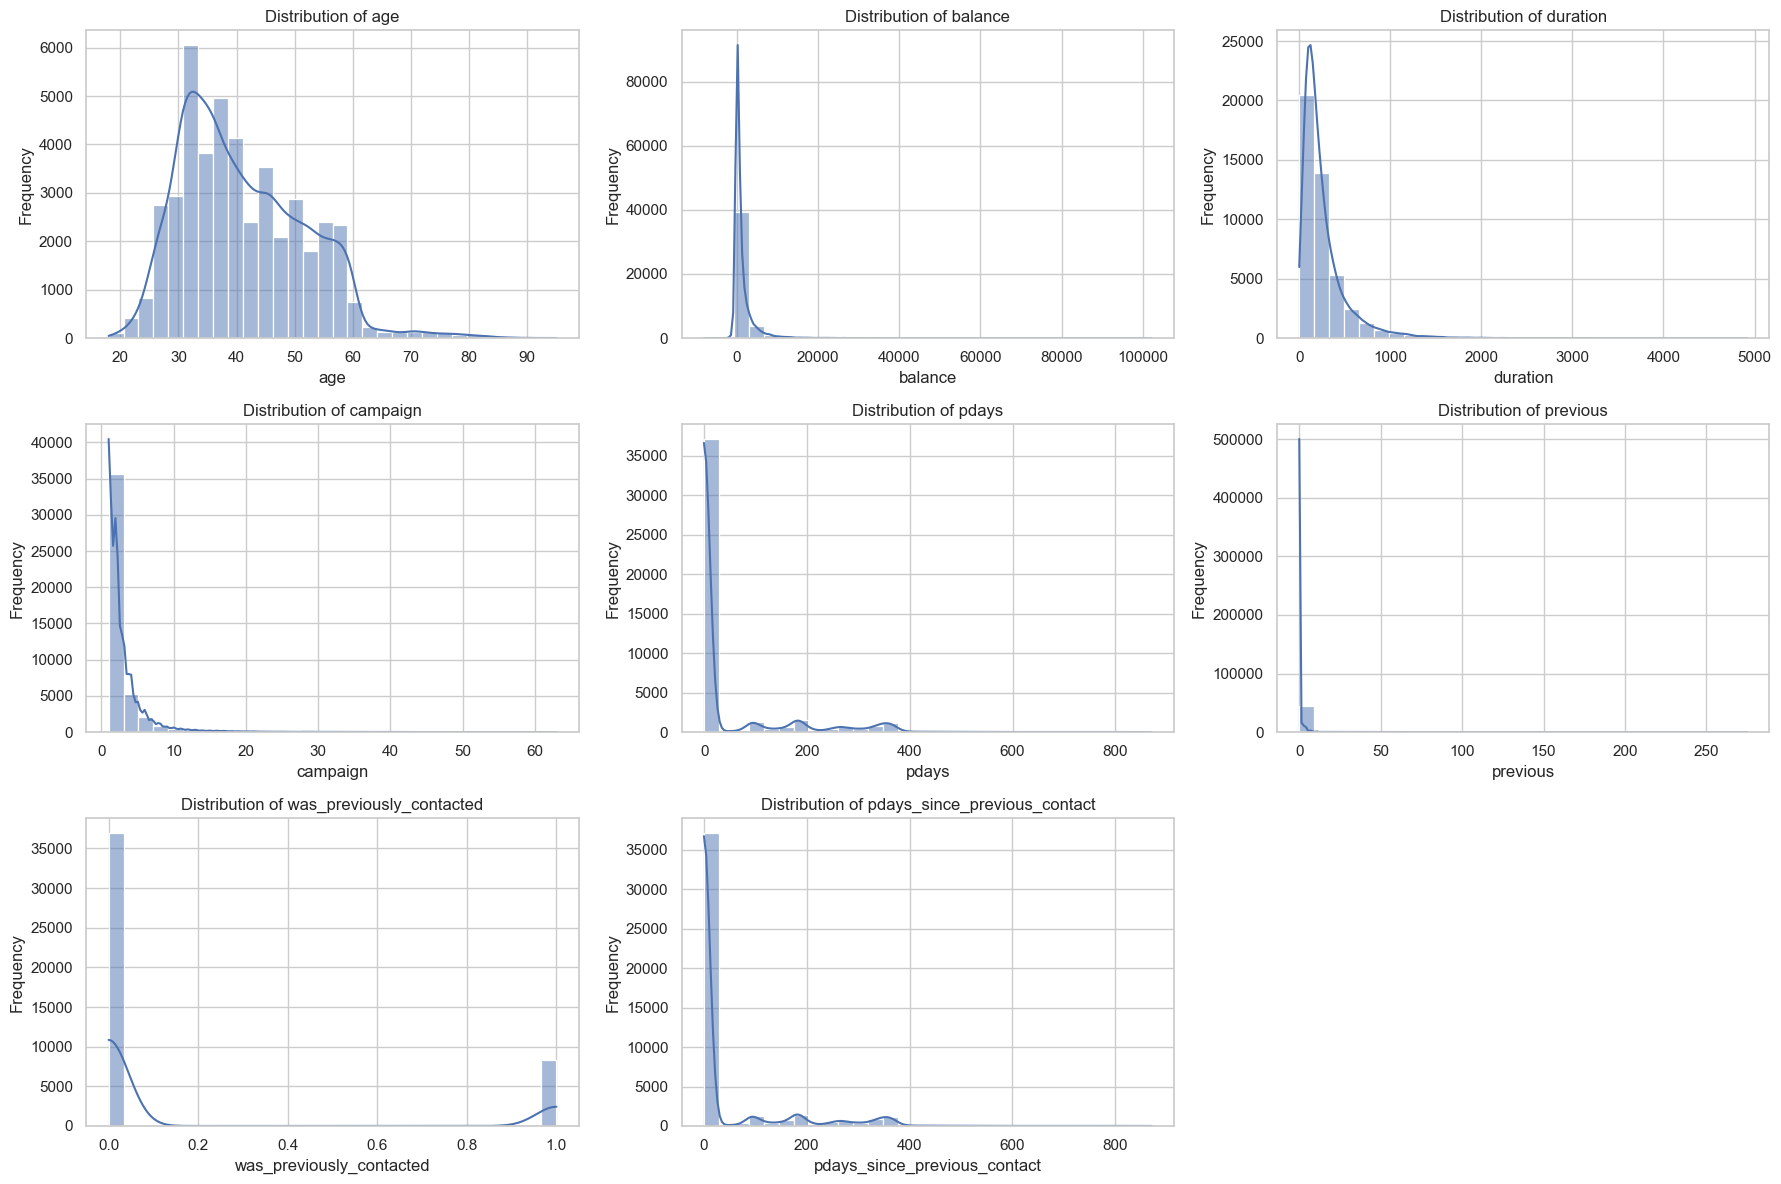

In [22]:

# Histograms of numerical variables
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The histogram analysis shows that some numerical variables have highly skewed distributions, with strong concentration around a few values and the presence of long tails.

This behavior is especially evident in variables such as `balance`, `campaign`, `previous` and `pdays_since_previous_contact`.

This skewness will not be treated directly in the original dataframe at this stage, because the need for transformation depends on the type of model used and also to avoid data leakage.

Tree-based models, such as Random Forest and CatBoost, tend to handle skewed distributions and outliers better, while models such as Logistic Regression and SVM are more sensitive to the scale and shape of variable distributions.

For this reason, any transformations will be applied inside the modeling pipelines, avoiding changes to the original dataset and reducing the risk of inconsistency between training and test data.

The `duration` variable, although highly skewed and probably strongly related to the target, will be removed before modeling because it represents information leakage, since it is only known after the contact with the customer.

The `pdays` variable will also not be used directly in modeling because it contains the special value -1, which indicates absence of previous contact. Instead, the derived variables `was_previously_contacted` and `pdays_since_previous_contact` will be used.


### 2.4.2 Outliers


I will visually analyze the presence of outliers using boxplots and quantitatively using the interquartile range.

It is important to remember that not every outlier represents an error. In `balance`, some customers are expected to have very high or very low balances. This information is relevant to subscription behavior.


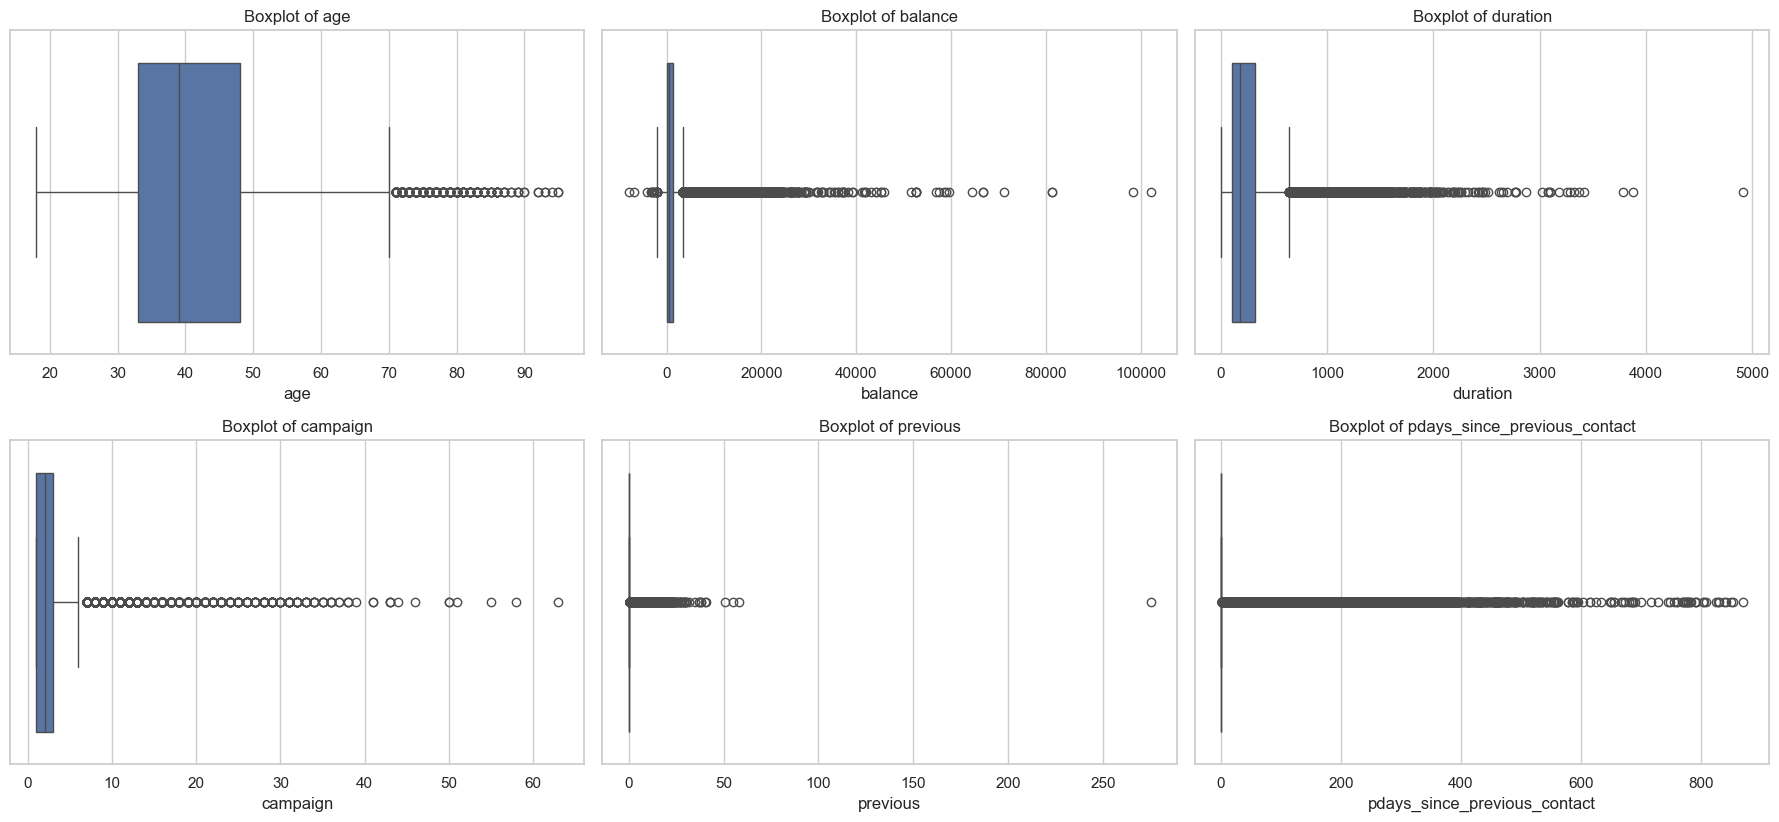

In [23]:

# Selecting only the variables that make sense to inspect with boxplots
boxplot_features = [f for f in numeric_features if f not in ["was_previously_contacted", "pdays"]]

# Boxplots of numerical variables
plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(boxplot_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [24]:

outlier_summary = []

for col in ["age", "balance", "duration", "campaign", "previous", "pdays_since_previous_contact"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    qtt_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    perc_outliers = qtt_outliers / len(df) * 100
    
    outlier_summary.append({
        "variavel": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "quantity_outliers": qtt_outliers,
        "percentage_outliers": perc_outliers
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values(by="percentage_outliers", ascending=False)
)

outlier_summary

,variavel,q1,q3,iqr,Lower_Bound,Upper_Bound,quantity_outliers,percentage_outliers
4,previous,0.0000,0.0000,0.0000,0.0000,0.0000,8257,18.2633
5,pdays_since_previous_contact,0.0000,0.0000,0.0000,0.0000,0.0000,8257,18.2633
1,balance,72.0000,"1,428.0000","1,356.0000","-1,962.0000","3,462.0000",4729,10.4598
2,duration,103.0000,319.0000,216.0000,-221.0000,643.0000,3235,7.1553
3,campaign,1.0000,3.0000,2.0000,-2.0000,6.0000,3064,6.7771
0,age,33.0000,48.0000,15.0000,10.5000,70.5000,487,1.0772


Based on the boxplots and the table, some numerical variables show many points outside the limits defined by the interquartile range (IQR).

However, these points will not be removed automatically. In real problems, extreme values may represent valid and relevant business behaviors.

For example, the variable `balance` may show very high or negative values, reflecting different customer financial profiles. The variable `campaign` may show high values for customers who received many contacts during the campaign. The variable `previous` may also take high values for customers with a more intense history of previous interactions.

Therefore, the presence of outliers will be treated as a characteristic of the dataset, not necessarily as a data error or noise.

The rationale is that removing them could eliminate informative records and distort the real data distribution. Instead, treatment will be handled specifically inside the modeling pipelines to avoid data leakage.

Tree-based models such as Random Forest and CatBoost tend to be less sensitive to outliers and skewed distributions. Models such as Logistic Regression and SVM may be more affected by scale and extreme values. For these models, techniques such as `RobustScaler`, which is less sensitive to outliers, or other appropriate transformations will be evaluated inside the preprocessing pipeline.


### 2.4.3 Relationship Between Explanatory Variables

This step is important to identify possible redundancy, multicollinearity and strong associations between variables.

Highly correlated or strongly associated variables may carry similar information. This does not mean they should be removed automatically, but this information will be considered later in feature selection and model interpretation.


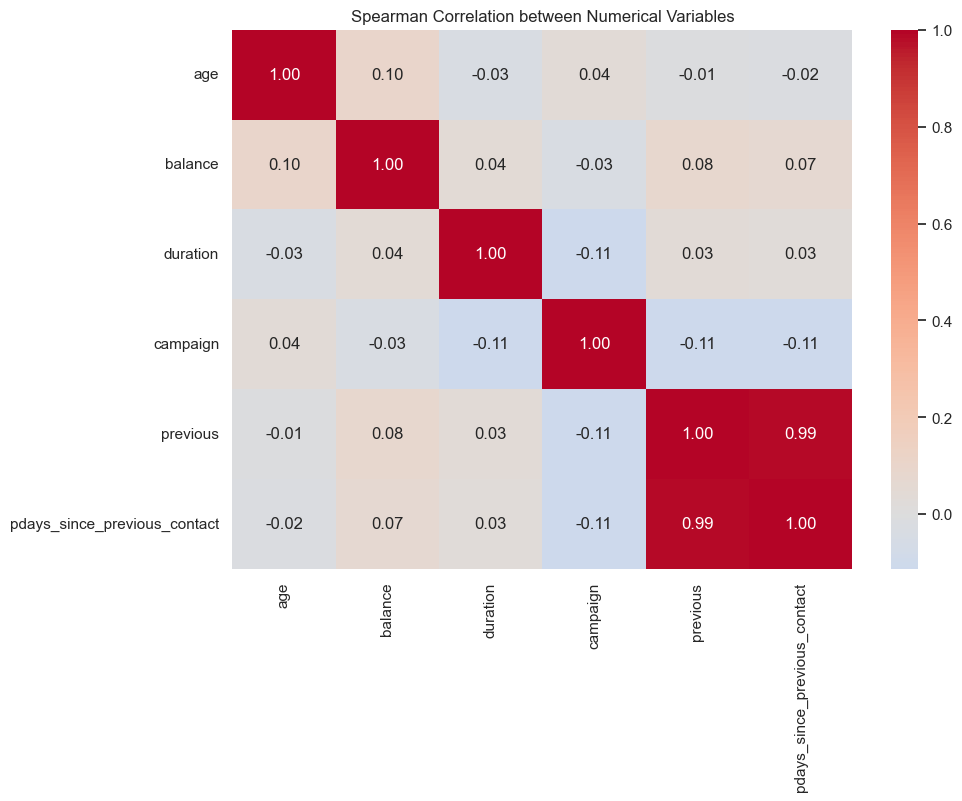

In [25]:
# Monotonic correlation between numerical variables

# `was_previously_contacted` is binary. As for `pdays`, we already created variables from it
# that will be used in modeling instead of it
corr_features = [f for f in numeric_features if f not in ["was_previously_contacted", "pdays"]]

corr_spearman = df[corr_features].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation between Numerical Variables")
plt.show()

Spearman correlation was used because it is more appropriate when variables have skewed distributions, long tails or monotonic relationships that are not necessarily linear.

Values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship and values close to 0 indicate low monotonic association.

It can be observed that only the variables `previous` (contacts with this customer before this campaign) and `pdays_since_previous_contact` (number of days since the last contact) showed a strong relationship with each other, indicating redundancy. Customers who had never been contacted before tend to have value zero in both variables, while customers previously contacted tend to have positive values.

This information will be considered later in feature selection.


In [26]:
# Cramer's V for the analysis of categorical variables

def cramers_v(x, y):
    matriz = pd.crosstab(x, y)
    
    chi2 = chi2_contingency(matriz)[0]
    n = matriz.sum().sum()
    
    r, k = matriz.shape
    phi2 = chi2 / n
    
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    
    denominador = min(k_corr - 1, r_corr - 1)
    
    if denominador == 0:
        return np.nan
    
    return np.sqrt(phi2_corr / denominador)

# Cramer's V matrix between categorical variables

cramers_matrix = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    dtype=float
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix

,job,marital,education,default,housing,loan,contact,month,poutcome,day_period
job,1.0000,0.2054,0.4580,0.0330,0.2813,0.1054,0.1497,0.1091,0.0623,0.0623
marital,0.2054,1.0000,0.1214,0.0180,0.0196,0.0515,0.0446,0.0706,0.0279,0.0248
education,0.4580,0.1214,1.0000,0.0137,0.1191,0.0799,0.1225,0.1090,0.0347,0.0362
default,0.0330,0.0180,0.0137,0.9994,0.0035,0.0769,0.0235,0.0566,0.0396,0.0156
housing,0.2813,0.0196,0.1191,0.0035,1.0000,0.0410,0.2135,0.5040,0.1429,0.0896
loan,0.1054,0.0515,0.0799,0.0769,0.0410,0.9999,0.0149,0.1822,0.0546,0.0289
contact,0.1497,0.0446,0.1225,0.0235,0.2135,0.0149,1.0000,0.5119,0.2073,0.0420
month,0.1091,0.0706,0.1090,0.0566,0.5040,0.1822,0.5119,1.0000,0.2138,0.3760
poutcome,0.0623,0.0279,0.0347,0.0396,0.1429,0.0546,0.2073,0.2138,1.0000,0.0721
day_period,0.0623,0.0248,0.0362,0.0156,0.0896,0.0289,0.0420,0.3760,0.0721,1.0000


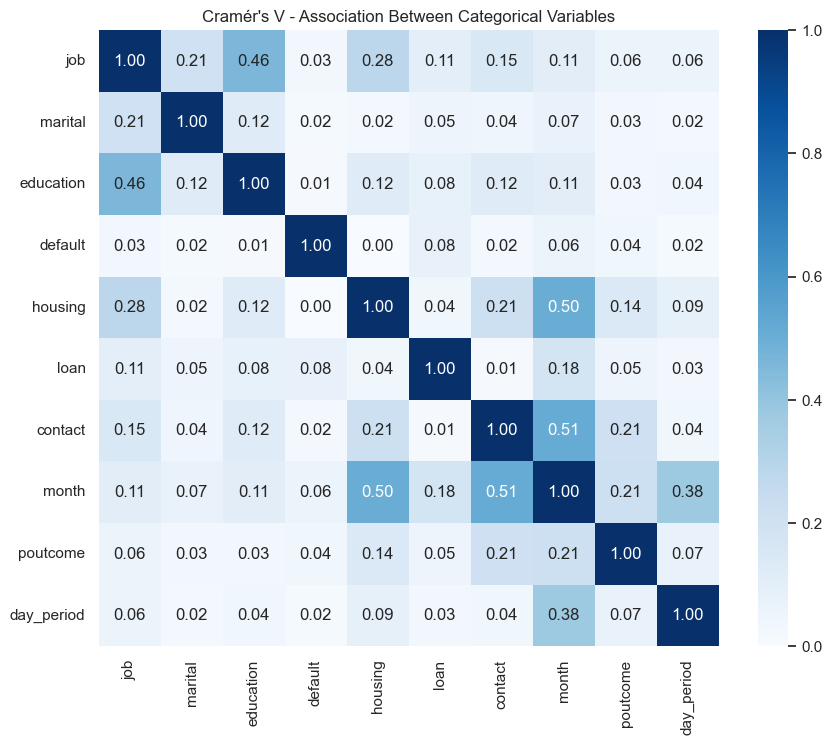

In [27]:
# Plotting the matrix

plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Cramér's V - Association Between Categorical Variables")
plt.show()

Cramér's V measures the strength of association between categorical variables.

In general, most associations between categorical variables were low, indicating that the variables do not seem to carry highly redundant information.

The most relevant associations observed were:

- `contact` and `month`, with Cramér's V close to 0.51;
- `housing` and `month`, with Cramér's V close to 0.50;
- `job` and `education`, with Cramér's V close to 0.46.

The association between `job` and `education` is coherent, since job type and education level may be related.

The associations involving `month`, `contact` and `housing` indicate that there may be some campaign pattern or dataset composition varying across months.

The association between `month` and `day_period`, although weaker, indicates a slight tendency for campaign contacts to occur in certain periods of the same months. For example, it is expected that there are not many contacts at the end of December because of Christmas.


### 2.4.4 Relationship Between Explanatory Variables and the Target

To evaluate the relationship between numerical variables and the target, I will first transform the target into a numerical variable.


In [28]:

# Creation of the binary target
df["target_binary"] = df["y"].map({"no": 0, "yes": 1})

df[["y", "target_binary"]].sample(5)

,y,target_binary
20519,no,0
35795,no,0
22882,no,0
33590,no,0
17861,no,0


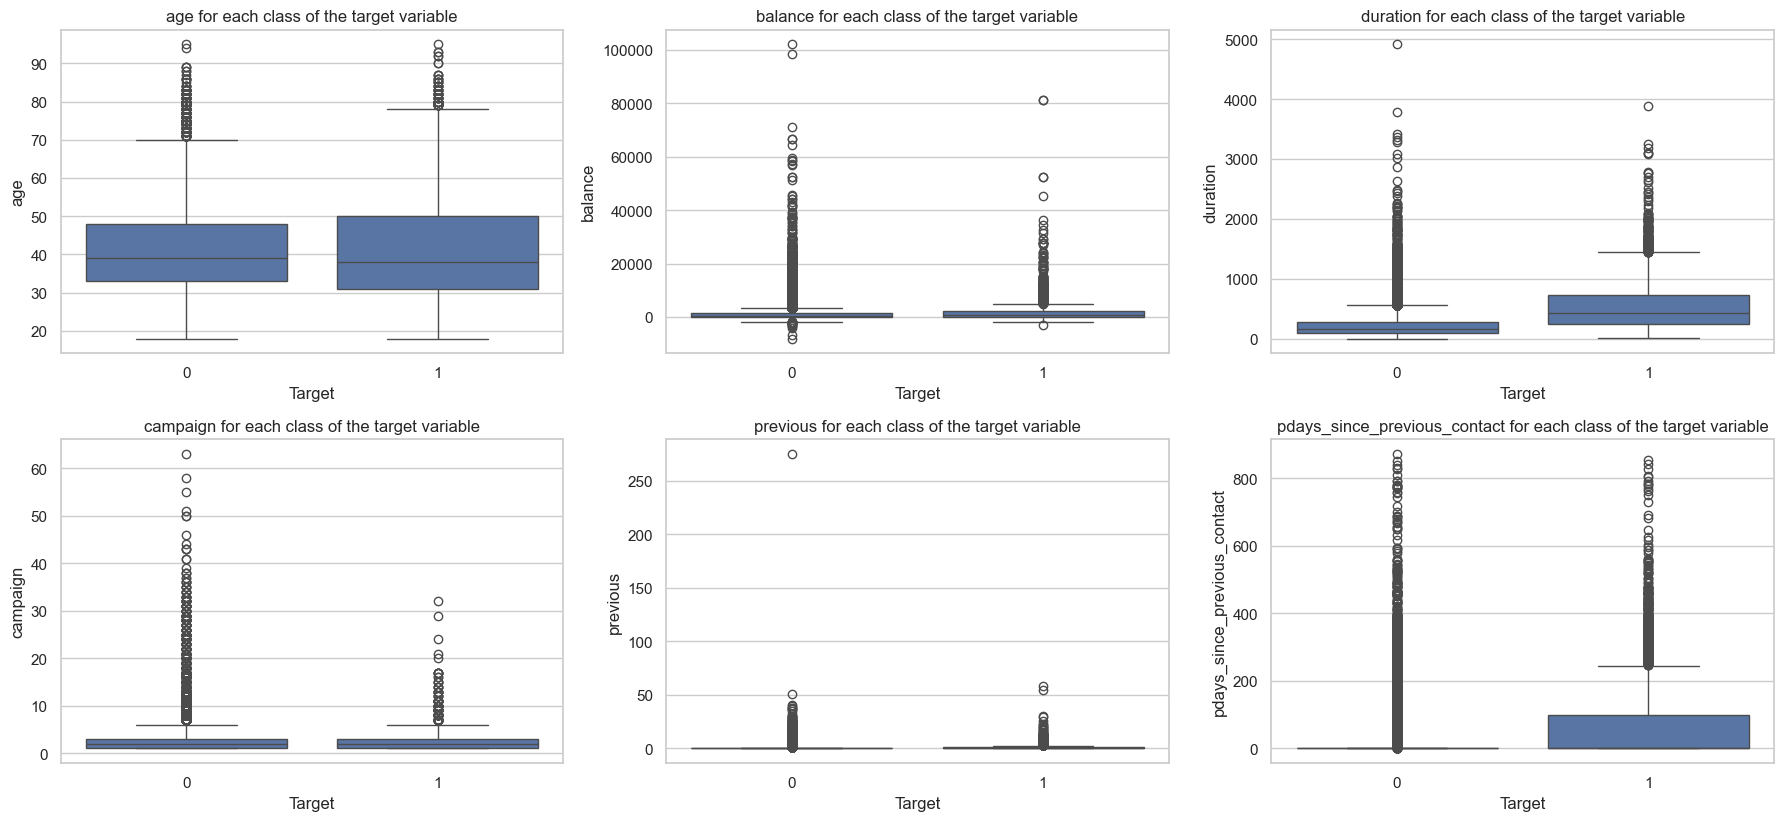

In [29]:
# Boxplots of numerical variables by target
plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(corr_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x="target_binary", y=col)
    plt.title(f"{col} for each class of the target variable")
    plt.xlabel("Target")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [30]:
# The variable `was_previously_contacted`
df.groupby("target_binary")["was_previously_contacted"].value_counts(normalize=True)

target_binary  was_previously_contacted
0              0                          0.8409
               1                          0.1591
1              0                          0.6398
               1                          0.3602
Name: proportion, dtype: float64

In [31]:
# Spearman correlation of numerical variables with the binary target
numeric_target_corr = (
    df[numeric_features + ["target_binary"]]
    .corr(method="spearman")["target_binary"]
    .drop("target_binary")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

numeric_target_corr

duration                        0.3425
previous                        0.1691
was_previously_contacted        0.1673
pdays                           0.1541
pdays_since_previous_contact    0.1541
balance                         0.1003
campaign                       -0.0841
age                            -0.0087
Name: target_binary, dtype: float64

Spearman correlation with the binary target indicates whether there is a monotonic relationship between each numerical variable and the probability of subscription.

This analysis does not capture all possible types of relationship, but it provides a first simple and interpretable measure of association between each numerical variable and the target.

Positive values indicate that higher values of the variable tend to be associated with a higher subscription rate. Negative values indicate the opposite.

The variable `duration` showed the strongest association with the target, with Spearman correlation of approximately 0.34. The boxplots also indicate that customers who subscribed to the product tend to have longer contact duration. As already discussed, this variable would cause data leakage and will not be used in modeling, but here we can see how it is associated with the target.

Among the remaining variables, those related to previous contact history stand out: `previous`, `was_previously_contacted` and `pdays_since_previous_contact`. These variables have a positive association with the target, suggesting that customers with previous contact history may have higher propensity to subscribe to the term deposit. On the other hand, the variable `campaign` has a negative relationship with the target, suggesting that customers who required more contacts during the campaign tend to have lower conversion propensity. Another detail is the association between `previous` and the target and between `pdays_since_previous_contact` and the target. Earlier, we saw that these variables are strongly associated with each other, at least according to Spearman correlation, but they separate the target in different ways, which suggests that they may provide different information to the model.

Overall, the analysis indicates that the most relevant numerical variables, excluding `duration`, seem to be related to previous contact history and campaign behavior.


For categorical variables, I will use the subscription rate by category and Cramér's V.


In [32]:
# Overall subscription rate
overall_subscription_rate = df["target_binary"].mean()

print(f"Overall Subscription Rate: {overall_subscription_rate:.2%}")

Overall Subscription Rate: 11.70%


In [33]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'day_period']

In [34]:

# Subscription rate by category
for col in categorical_features:
    print("=" * 80)
    print(f"Variable: {col}")
    
    summary = (
        df.groupby(col)["target_binary"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "quantity",
            "mean": "subscription_rate"
        })
        .sort_values("subscription_rate", ascending=False)
    )
    
    summary["subscription_rate"] = (summary["subscription_rate"] * 100).round(2)
    
    display(summary)

Variable: job


,quantity,subscription_rate
job,,
student,938,28.6800
retired,2264,22.7900
unemployed,1303,15.5000
management,9458,13.7600
admin.,5171,12.2000
self-employed,1579,11.8400
unknown,288,11.8100
technician,7597,11.0600
services,4154,8.8800


Variable: marital


,quantity,subscription_rate
marital,,
single,12790,14.9500
divorced,5207,11.9500
married,27214,10.1200


Variable: education


,quantity,subscription_rate
education,,
tertiary,13301,15.0100
unknown,1857,13.5700
secondary,23202,10.5600
primary,6851,8.6300


Variable: default


,quantity,subscription_rate
default,,
no,44396,11.8000
yes,815,6.3800


Variable: housing


,quantity,subscription_rate
housing,,
no,20081,16.7000
yes,25130,7.7000


Variable: loan


,quantity,subscription_rate
loan,,
no,37967,12.6600
yes,7244,6.6800


Variable: contact


,quantity,subscription_rate
contact,,
cellular,29285,14.9200
telephone,2906,13.4200
unknown,13020,4.0700


Variable: month


,quantity,subscription_rate
month,,
mar,477,51.9900
dec,214,46.7300
sep,579,46.4600
oct,738,43.7700
apr,2932,19.6800
feb,2649,16.6500
aug,6247,11.0100
jun,5341,10.2200
nov,3970,10.1500


Variable: poutcome


,quantity,subscription_rate
poutcome,,
success,1511,64.7300
other,1840,16.6800
failure,4901,12.6100
unknown,36959,9.1600


Variable: day_period


,quantity,subscription_rate
day_period,,
early_month,13725,12.6300
late_month,13097,11.6900
mid_month,18389,11.0100


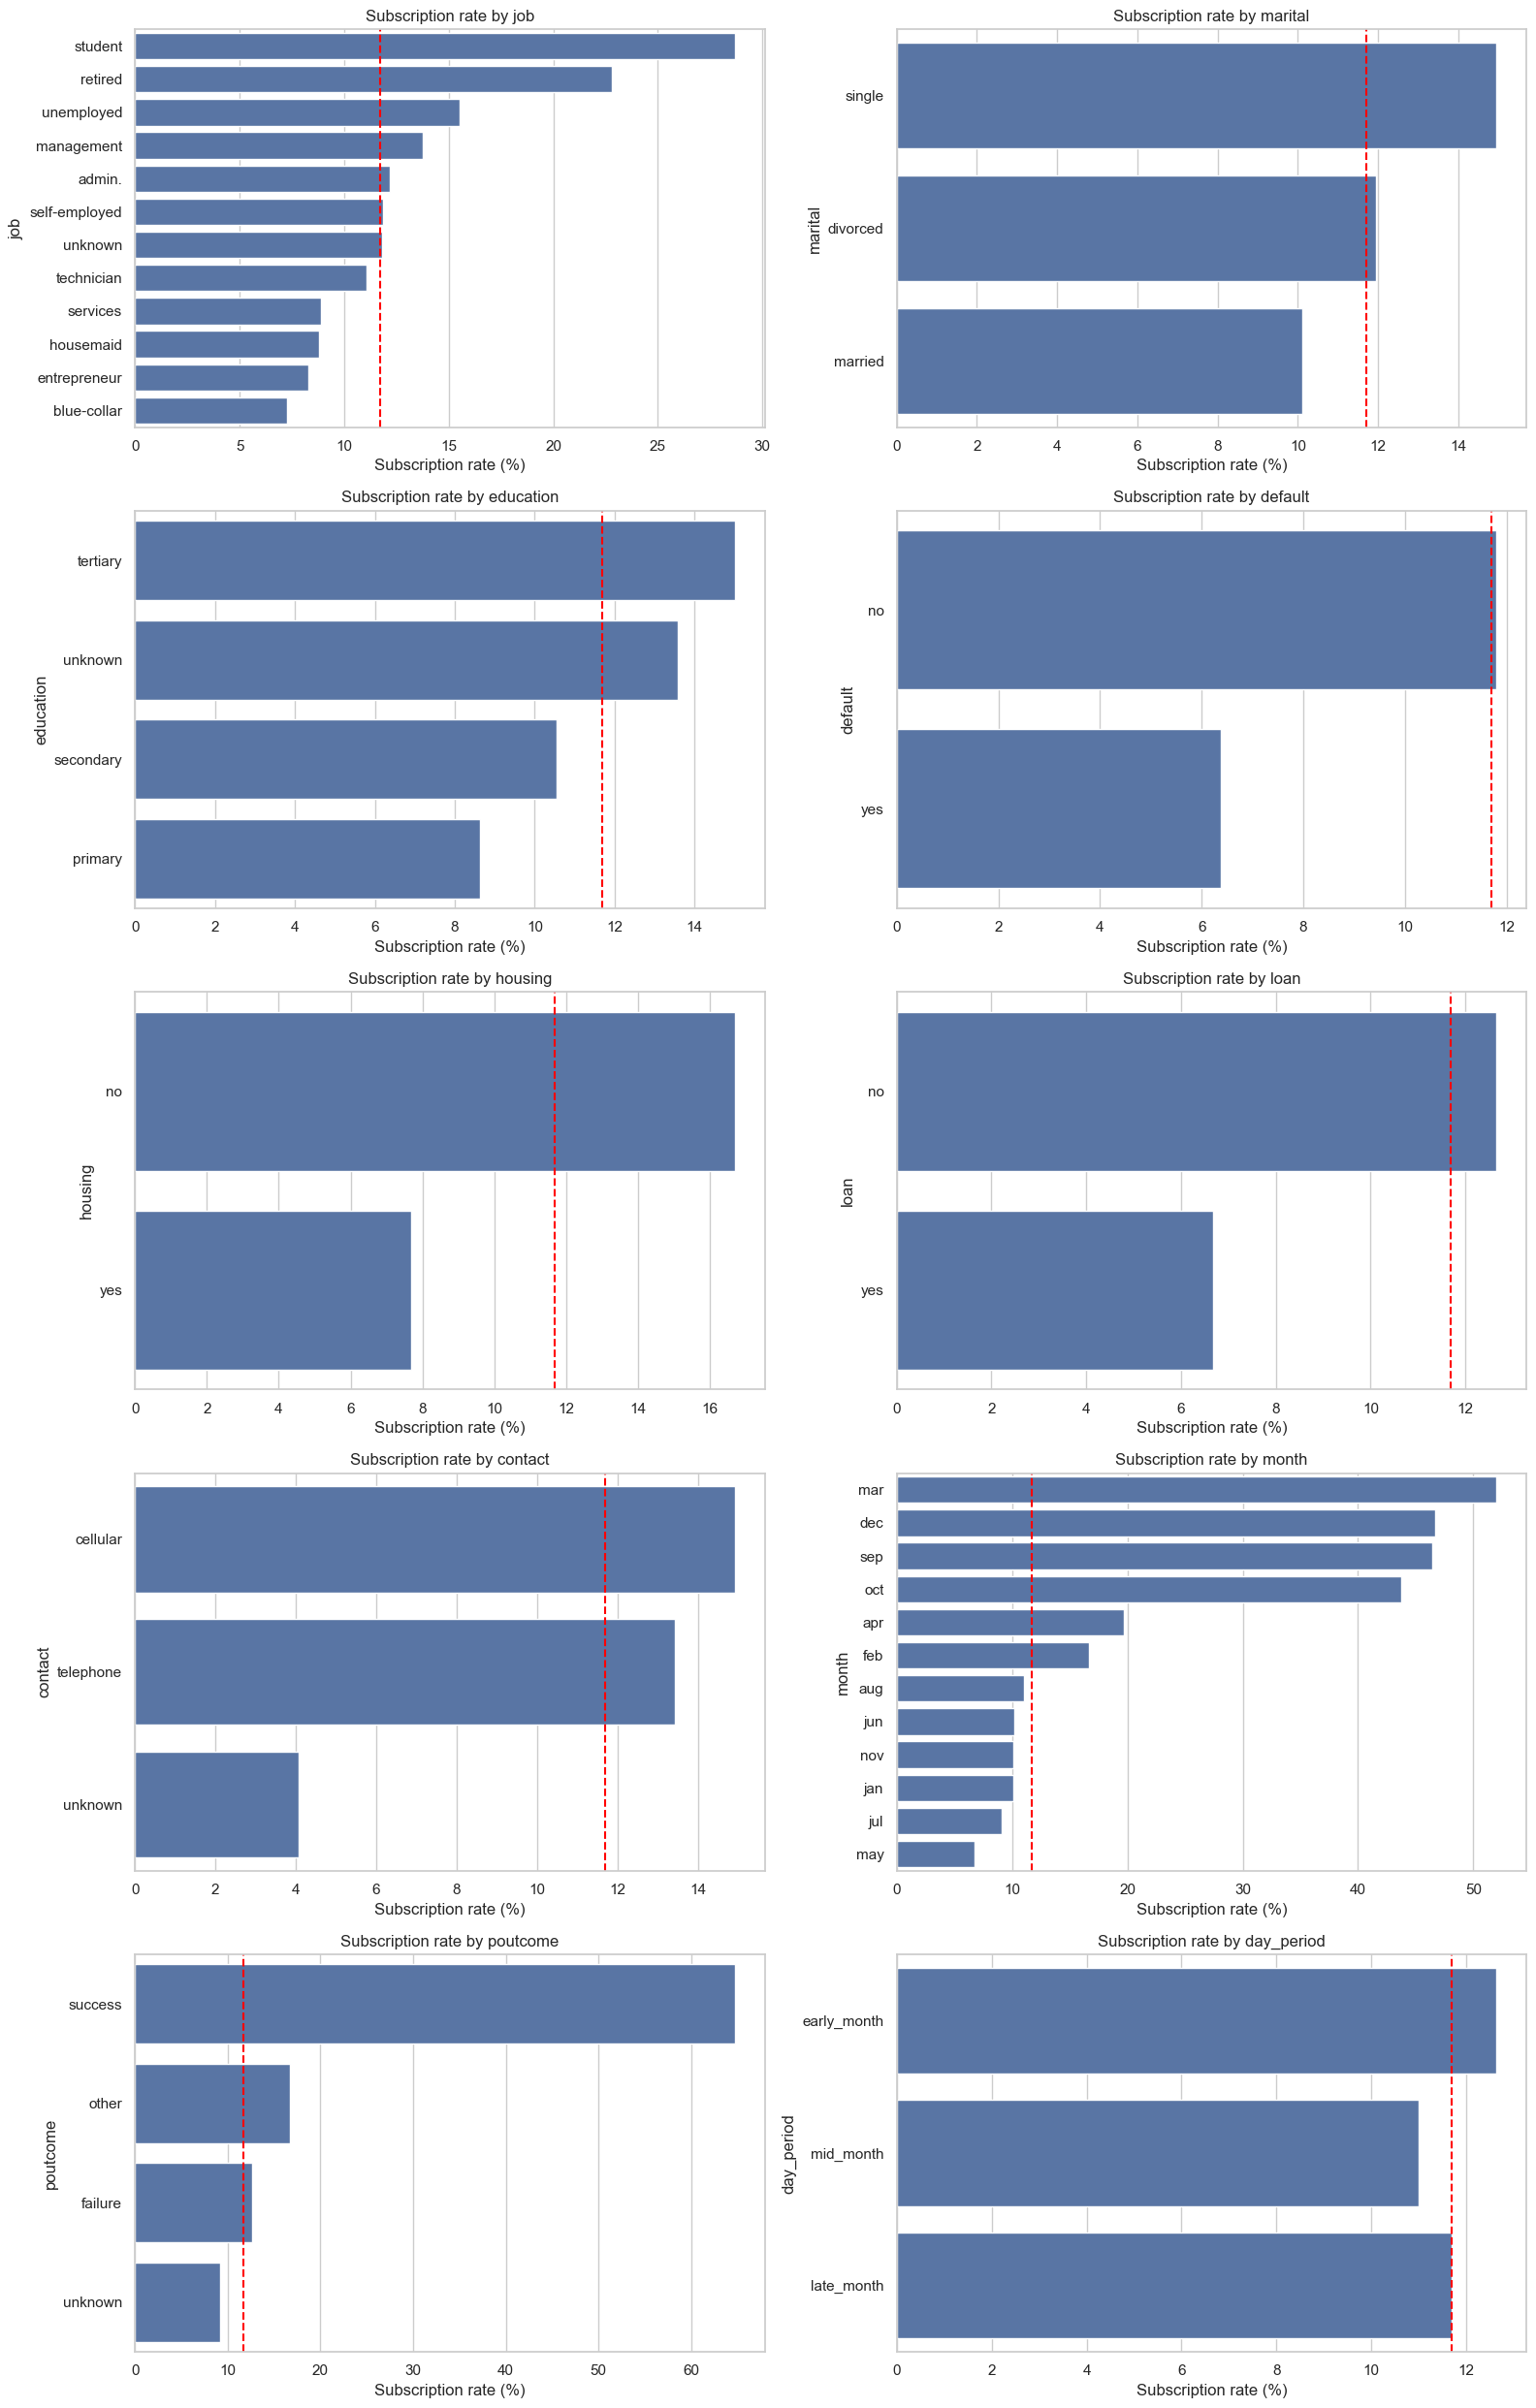

In [35]:
# Subscription rate charts by category
n_cols = 2
n_rows = int(np.ceil(len(categorical_features) / n_cols))

plt.figure(figsize=(16, 5 * n_rows))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    
    taxa = (
        df.groupby(col)["target_binary"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
    )
    
    sns.barplot(x=taxa.values, y=taxa.index)
    plt.axvline(overall_subscription_rate * 100, color="red", linestyle="--", label="Overall rate")
    
    plt.title(f"Subscription rate by {col}")
    plt.xlabel("Subscription rate (%)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [36]:

# Cramer's V of categorical variables with the target
categorical_target_association = []

for col in categorical_features:
    categorical_target_association.append({
        "variable": col,
        "cramers_v_with_target": cramers_v(df[col], df["y"])
    })

categorical_target_association = (
    pd.DataFrame(categorical_target_association)
    .sort_values("cramers_v_with_target", ascending=False)
)

categorical_target_association

,variable,cramers_v_with_target
8,poutcome,0.3116
7,month,0.2598
6,contact,0.1512
4,housing,0.1390
0,job,0.1351
2,education,0.0722
5,loan,0.0679
1,marital,0.0656
3,default,0.0217
9,day_period,0.0200


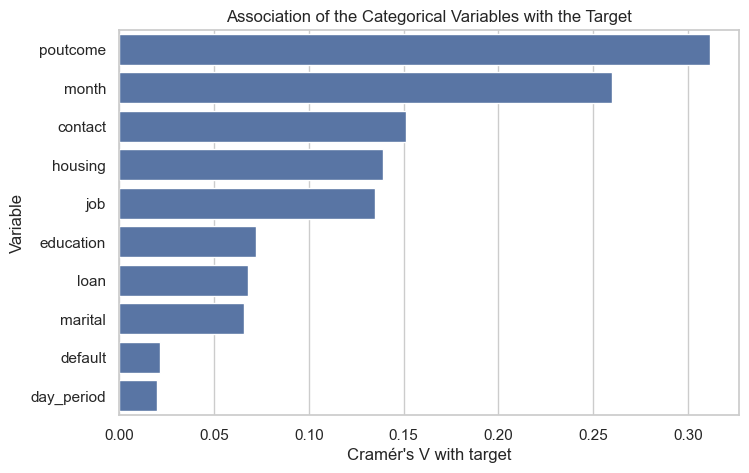

In [37]:

plt.figure(figsize=(8, 5))

sns.barplot(
    data=categorical_target_association,
    x="cramers_v_with_target",
    y="variable"
)

plt.title("Association of the Categorical Variables with the Target")
plt.xlabel("Cramér's V with target")
plt.ylabel("Variable")
plt.show()

The average subscription rate to the term deposit in the dataset is approximately **11.7%**. The analysis by category shows that some variables have relevant differences in subscription rates across groups.

The variables with the strongest association with the target, according to Cramér's V, were:

- `poutcome` - 0.3116;
- `month` - 0.2598;
- `contact` - 0.1512;
- `housing` - 0.1390;
- `job` - 0.1351.

The variable `poutcome` showed the strongest association with the target. Customers whose previous campaign outcome was `success` had a subscription rate well above the average, indicating that previous campaign success is highly relevant information.

The variable `month` also showed a relevant association. Some months, such as `mar`, `dec`, `sep` and `oct`, had subscription rates well above average, while months such as `may`, `jul`, `jan` and `nov` were below average. This may indicate seasonality or operational differences between campaign periods.

The variable `contact` showed a clear difference between channels. Contacts by `cellular` and `telephone` had subscription rates higher than the `unknown` category, suggesting that the communication channel may be related to campaign effectiveness.

The variables `housing`, `loan` and `default` show that customers without a housing loan, without a personal loan and without default tend to have higher subscription rates than their opposite groups, which makes sense for an investment product.

In `job`, categories such as `student`, `retired`, `unemployed` and `management` had above-average rates, while `blue-collar`, `entrepreneur`, `housemaid` and `services` were below average. This suggests that occupational profile may help distinguish subscription propensity. Some of these category behaviors are expected: students and unemployed people tend to prefer lower-risk investments, while blue-collar workers and entrepreneurs may generally have a lower aversion to riskier products, although they may still subscribe to the studied product as a way to diversify their portfolio.

The variables `education`, `marital`, `loan`, `default` and `marital` had lower Cramér's V values, indicating weaker association with the target when evaluated individually.

Overall, the most relevant categorical variables for modeling seem to be `poutcome`, `month`, `contact`, `housing` and `job`.


## 2.5 Feature Selection

Based on the exploratory analysis, variables with conceptual problems or risk of information leakage will be removed from modeling.

The variable `duration` will be removed because it represents the duration of the contact with the customer. This information is only known after the call and, therefore, would not be available at the real decision moment before the campaign. Using it in the model would create information leakage (*data leakage*).

The variable `pdays` will also not be used directly because it contains the special value -1, which indicates absence of previous contact. To represent this information more appropriately, the variables `was_previously_contacted` and `pdays_since_previous_contact` were created.

The remaining variables will initially be kept. The exploratory analysis indicated possible redundancy between `previous` and `pdays_since_previous_contact` regarding monotonic correlation, but also different capacities to separate the target classes. I tested using both variables and using only `previous`, and the metrics were slightly better with both. The difference is very small. I chose to keep both.


In [38]:

# Target variable
target = "target_binary"

# Variables that will not be used in modeling
drop_features = [
    "duration",         # data-leakage
    "pdays",            # replaced by other variables
    "target_binary",    # target variable, now binary
    "y"                 # original target variable
]

# Candidate variables for modeling
candidate_features = [
    col for col in df.columns
    if col not in drop_features
]

print(candidate_features)

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'day_period', 'was_previously_contacted', 'pdays_since_previous_contact']


In [39]:
X = df[candidate_features].copy()
y = df[target]

print("X's shape:", X.shape)
print("y's shape:", y.shape)

X's shape: (45211, 16)
y's shape: (45211,)


In [40]:
# First split: separating the test data
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: splitting training and calibration
# X_temp represents 80% of the original dataset.
# To obtain 20% of the original dataset for calibration, we use 0.25 of X_temp (1/4 of 80%).
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Calibration:", X_calib.shape, y_calib.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (27126, 16) (27126,)
Calibration: (9042, 16) (9042,)
Test: (9043, 16) (9043,)


In [41]:
# Checking class balance after the split
split_balance = pd.DataFrame({
    "training": y_train.value_counts(normalize=True).sort_index(),
    "calibration": y_calib.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}).T

split_balance.columns = ["classe_0_no", "classe_1_yes"]
split_balance = split_balance.mul(100).round(2)

split_balance

,classe_0_no,classe_1_yes
training,88.3000,11.7000
calibration,88.3000,11.7000
test,88.3000,11.7000


The dataset was split in a stratified way, approximately preserving the same proportion between the `no` and `yes` classes in the training, calibration and test sets.

The training set will be used to fit the models. Even transformations such as encoding will be fitted on this set first (`fit_transform`) to avoid data leakage. For CatBoost, I will test using categorical variables as they are, because the algorithm has native handling for this type of variable.

The calibration set will later be used to calibrate predicted probabilities and estimate uncertainty intervals.

The test set will be kept separate until the end and used only for final evaluation of the selected model.


In [42]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 27126 entries, 10333 to 10753
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   age                           27126 non-null  int64   
 1   job                           27126 non-null  str     
 2   marital                       27126 non-null  str     
 3   education                     27126 non-null  str     
 4   default                       27126 non-null  str     
 5   balance                       27126 non-null  int64   
 6   housing                       27126 non-null  str     
 7   loan                          27126 non-null  str     
 8   contact                       27126 non-null  str     
 9   month                         27126 non-null  str     
 10  campaign                      27126 non-null  int64   
 11  previous                      27126 non-null  int64   
 12  poutcome                      27126 non-null  str     
 13

## 2.6 Modeling


### 2.6.1 Baseline (DummyClassifier)

The baseline will use the strategy of always predicting the majority class from the training set. Since most customers did not subscribe to the term deposit, this model is expected to classify all records as `no`.

This baseline is important because any final model must outperform a naive rule. Otherwise, the model would not be adding real value to the decision process.


In [43]:

# Baseline: always predicts the majority class
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)

dummy_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred_dummy = dummy_clf.predict(X_test)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

In [44]:

# Baseline metrics
baseline_metrics = {
    "precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    # F0.5-score with beta < 1 means we give more weight to Precision
    # in the F1-score calculation.
    "f0_5": fbeta_score(y_test, y_pred_dummy, beta=0.5, zero_division=0),
    "pr_auc": average_precision_score(y_test, y_proba_dummy),
    "brier_score": brier_score_loss(y_test, y_proba_dummy),
    "log_loss": log_loss(y_test, y_proba_dummy)
}

baseline_metrics

{'precision': 0.0,
 'recall': 0.0,
 'f0_5': 0.0,
 'pr_auc': 0.11699657193409267,
 'brier_score': 0.11699657193409267,
 'log_loss': 4.216983886507348}

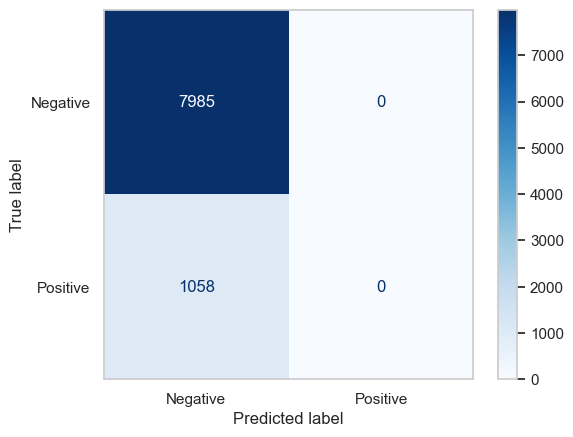

In [45]:

# Baseline confusion matrix
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
disp_dummy = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=["Negative", "Positive"])
disp_dummy.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

In [46]:

# Classification report
print(classification_report(y_test, y_pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7985
           1       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



It can be observed that accuracy is high, at 0.88, even with a “naive” classifier, due to class imbalance. This is why this metric is misleading in this case and is not useful for us.

From the confusion matrix, we see that there are no positives at all, neither true positives nor false positives.

For the positive class, the metrics are very poor, as expected. The baseline PR-AUC is an important reference because, in a classifier with no real separation ability, it tends to be close to the prevalence of the positive class in the dataset. In this case, it was 0.11, a very poor result.

These metrics show that the classifier has no ability to separate the classes and would not identify any customer likely to subscribe to the product.

Therefore, the trained models must at least outperform this baseline, especially on metrics related to the positive class.


### 2.6.2 Preprocessing for Scikit-Learn Models

These models require all variables to be in numerical format, unlike CatBoost, which will be used later.

I will create a pipeline to handle these values, with different treatment for numerical and categorical variables: One-Hot-Encoding for categorical variables and, for numerical variables, the transformation will depend on the model. For models sensitive to data scale, I will use RobustScaler (less sensitive to outliers than PowerTransformer, which could be used with the Yeo-Johnson method to handle negative numbers) and StandardScaler, depending on the variable. I will separate the binary variable because it does not need transformation. For Random Forest, since it is a tree-based model, it is not necessary to change the scale of the data, at least in theory.

The transformations will be fitted on the training set to avoid leaking information to the calibration and test sets.


In [47]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 27126 entries, 10333 to 10753
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   age                           27126 non-null  int64   
 1   job                           27126 non-null  str     
 2   marital                       27126 non-null  str     
 3   education                     27126 non-null  str     
 4   default                       27126 non-null  str     
 5   balance                       27126 non-null  int64   
 6   housing                       27126 non-null  str     
 7   loan                          27126 non-null  str     
 8   contact                       27126 non-null  str     
 9   month                         27126 non-null  str     
 10  campaign                      27126 non-null  int64   
 11  previous                      27126 non-null  int64   
 12  poutcome                      27126 non-null  str     
 13

In [48]:

# Numerical and categorical variables

# `Age` has a distribution close to normal, so I will use StandardScaler
standard_numeric_features = [
                            "age"
                            ]

# These variables need transformation. I will use Yeo-Johnson because it accepts negative values
skewed_numeric_features = [
                            "balance",
                            "campaign",
                            "previous",
                            "pdays_since_previous_contact"
                            ]

# This variable is already binary, so it will not be transformed
binary_numeric_features = [
                            "was_previously_contacted"
                            ]

# Categorical variables
categorical_features_model = X_train.select_dtypes(
    include=["str", "category"]
).columns.tolist()

In [49]:
# OneHotEncoder (for Naive Bayes, we will use sparse_output=False because it does not work
# with sparse matrices)
onehot_sparse = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
onehot_dense = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Processing pipeline for models sensitive to data scale
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num_standard", StandardScaler(), standard_numeric_features),
        ("num_skewed", RobustScaler(), skewed_numeric_features),
        ("num_binary", "passthrough", binary_numeric_features),
        ("cat", onehot_sparse, categorical_features_model)
    ]
)

# Processing pipeline for Naive Bayes
preprocessor_scaled_dense = ColumnTransformer(
    transformers=[
        ("num_standard", StandardScaler(), standard_numeric_features),
        ("num_skewed", RobustScaler(), skewed_numeric_features),
        ("num_binary", "passthrough", binary_numeric_features),
        ("cat", onehot_dense, categorical_features_model)
    ],
    sparse_threshold=0
)

# Processing pipeline for Random Forest
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num_standard", "passthrough", standard_numeric_features),
        ("num_skewed", "passthrough", skewed_numeric_features),
        ("num_binary", "passthrough", binary_numeric_features),
        ("cat", onehot_sparse, categorical_features_model)
    ]
)

### 2.6.3 Initial Model Training

With the preprocessing pipelines defined, different candidate models will be trained.

The models will be fitted on the training set and evaluated on the test set.

At this stage, the objective is to compare the initial performance of the classifiers before probability calibration.

Variable transformations are applied within the pipelines, ensuring that the transformers are fitted only on the training data and later applied to the test set, avoiding data leakage.

Since the dataset is imbalanced, accuracy will not be used as the main evaluation metric. The comparison will focus on:

- metrics that penalize false positives, such as Precision, F0.5 and PR-AUC;
- a metric that penalizes false negatives: Recall;
- metrics that evaluate model performance regarding generated probabilities, such as Brier Score and Log Loss.


In [50]:
# Function for calculating metrics
def evaluate_model(model_name, model_, X_test, y_test):
    y_pred = model_.predict(X_test)
    y_proba = model_.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f0_5": fbeta_score(y_test, y_pred, beta=0.5, zero_division=0),
        "pr_auc": average_precision_score(y_test, y_proba),
        "brier_score": brier_score_loss(y_test, y_proba),
        "log_loss": log_loss(y_test, y_proba)
                }

    return metrics

In [51]:
# Model definition

# Base SVM
svm_base = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

# SVM with CalibratedClassifierCV
svm_calibrated = CalibratedClassifierCV(
    estimator=svm_base,
    method="sigmoid",
    cv=5,
    ensemble=False,
    n_jobs=-1
)


# Dictionary with the models
models = {
    "Logistic Regression": Pipeline(steps=[
                                            ("preprocessor", preprocessor_scaled),
                                            ("classifier", LogisticRegression(
                                                                                max_iter=1000,
                                                                                class_weight="balanced",
                                                                                random_state=42
                                                                            ))]),

    "Naive Bayes": Pipeline(steps=[
                                    ("preprocessor", preprocessor_scaled_dense),
                                    ("classifier", GaussianNB())
                                    ]),

    "SVM": svm_calibrated,

    "Random Forest": Pipeline(steps=[
                                    ("preprocessor", preprocessor_tree),
                                    ("classifier", RandomForestClassifier(
                                                                    n_estimators=300,
                                                                    class_weight="balanced",
                                                                    random_state=42,
                                                                    n_jobs=-1
                                                                            ))]),
    
    "CatBoost": CatBoostClassifier(
                                    iterations=500,
                                    learning_rate=0.05,
                                    depth=6,
                                    loss_function="Logloss",
                                    eval_metric="PRAUC",
                                    auto_class_weights="Balanced", 
                                    random_seed=42,
                                    verbose=False
                                    )
            }

Observation: The SVM model was implemented with `LinearSVC` combined with `CalibratedClassifierCV`.

This choice was made because SVC with an RBF kernel can be computationally expensive on datasets with tens of thousands of records. In addition, the `probability=True` parameter of `SVC` has been deprecated in recent versions of scikit-learn.

Since `LinearSVC` does not return probabilities directly, `CalibratedClassifierCV` with the sigmoid method was used to allow the calculation of predicted probabilities and metrics such as PR-AUC, Brier Score and Log Loss.

For CatBoost, I will let it perform its native transformations and evaluate the quality of the model this way, both for numerical and categorical variables.


In [52]:
# Model training
results = []

for name, model in models.items():
    print(f"Training model: {name}")

    if name == "CatBoost":
        model.fit(
                    X_train,
                    y_train,
                    cat_features=categorical_features_model
                    )
    else:
        model.fit(X_train, y_train)

    metricas = evaluate_model(name, model, X_test, y_test)
    results.append(metricas)

results_models = (
    pd.DataFrame(results)
    .sort_values(by="pr_auc", ascending=False)
    .reset_index(drop=True)
)

results_models

Training model: Logistic Regression
Training model: Naive Bayes
Training model: SVM
Training model: Random Forest
Training model: CatBoost


,model,precision,recall,f0_5,pr_auc,brier_score,log_loss
0,CatBoost,0.3591,0.6153,0.3917,0.4533,0.1512,0.4824
1,Random Forest,0.4643,0.3998,0.4498,0.4114,0.0978,0.3442
2,Logistic Regression,0.2693,0.6323,0.3043,0.4096,0.1837,0.5576
3,SVM,0.6589,0.1607,0.4067,0.4054,0.0856,0.2994
4,Naive Bayes,0.3482,0.4726,0.3675,0.3494,0.1519,2.1148


The evaluated models showed performance that was at least superior to the baseline. For PR-AUC, in an imbalanced dataset, the baseline should be close to the proportion of positives in the dataset (11.7%). The Log Loss and Brier Score of the models, except for Naive Bayes, also show a considerable classification gain, especially regarding probability estimates: the Brier Score measures the mean squared error of calculated probabilities, ranging from 0 to 1; Log Loss also penalizes errors based on the calculated probability, but it has no maximum value and applies a strong penalty to errors the model made with “confidence”, for example assigning probability 0.99 to a negative record.

Among the evaluated models, `CatBoost` achieved the highest `PR-AUC`, indicating the best ability to rank customers by subscription. It also had high recall, indicating a low number of false negatives. However, its precision was lower than Random Forest and SVM, indicating more false positives at the default threshold of 0.5. Since false positives are considered a problem in this study, it may be interesting to test different thresholds, because PR-AUC shows that precision, overall and not only at threshold 0.5, was above the other models.

`Random Forest` achieved the best `F0.5-score`, as well as a good balance between precision and recall. Since F0.5 gives more weight to precision, this result is important for this study. The model also had better Brier Score and Log Loss than CatBoost, suggesting initially better-adjusted probabilities.

`Logistic Regression` had the highest recall among the models, meaning few false negatives. However, its precision was low, indicating many false positives. Again, this may be a matter of threshold adjustment.

`SVM` had the highest precision among the models, but with very low recall. This means that when it classifies a customer as positive, it tends to be correct more often, but it classifies many customers who would actually subscribe as negative. It also had the best Brier Score and Log Loss values, indicating good initial quality of calibrated probabilities.

`Naive Bayes` performed worse than the others, especially in PR-AUC and Log Loss. The high Log Loss value suggests that its predicted probabilities are poorly adjusted, possibly due to excessive confidence in wrong predictions or predictions very close to the threshold.

The most promising models so far are:

* `CatBoost`, because of the highest PR-AUC and good recall, since threshold adjustment will decrease recall, so a high initial recall may be useful;
* `Random Forest`, because of the best overall balance and the highest F0.5-score;
* `SVM`, because of the highest precision and best initial probabilistic metrics.

The final choice should not be made only based on these results because all models were evaluated using the default threshold of 0.5. In the next step, I will analyze Precision-Recall curves, confusion matrices, different decision thresholds and probability calibration.


### 2.6.4 Evaluation of Precision-Recall Curves and Thresholds

At this stage, the three most promising models from the initial round will be evaluated:

- CatBoost;
- Random Forest;
- SVM.

The Precision-Recall curve allows evaluation of the trade-off between precision and recall at different decision thresholds.

Since the dataset is imbalanced and the focus of the problem is identifying the positive class (`yes`), this curve is more informative than metrics based on accuracy.

In addition, since false positives are especially relevant in this problem, I will analyze how different thresholds affect precision, recall and F0.5-score.


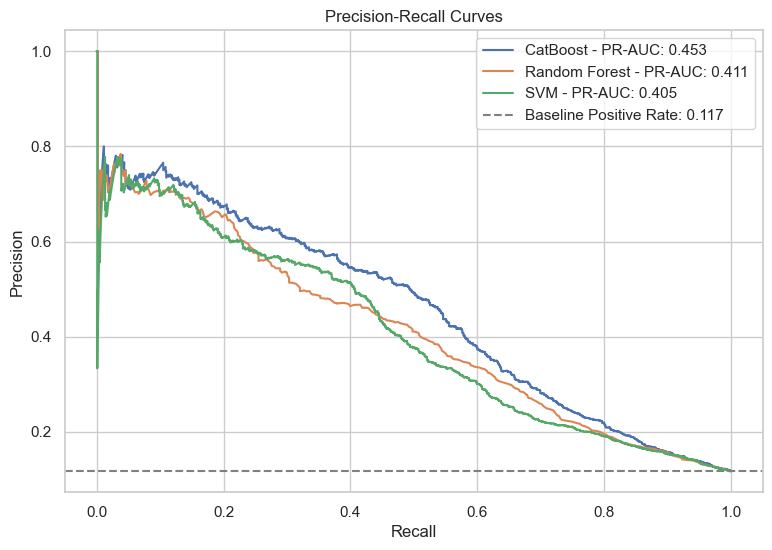

,model,pr_auc
0,CatBoost,0.4533
1,Random Forest,0.4114
2,SVM,0.4054


In [53]:
# Selected models
models_to_evaluate = {
    "CatBoost": models["CatBoost"],
    "Random Forest": models["Random Forest"],
    "SVM": models["SVM"]
                        }

# Precision-Recall curves

plt.figure(figsize=(9, 6))

pr_auc_results = []

for model_name, model in models_to_evaluate.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    pr_auc_results.append({
        "model": model_name,
        "pr_auc": pr_auc
    })
    
    plt.plot(
        recall,
        precision,
        label=f"{model_name} - PR-AUC: {pr_auc:.3f}"
    )

positive_rate = y_test.mean()

plt.axhline(
    positive_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline Positive Rate: {positive_rate:.3f}"
)

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

pd.DataFrame(pr_auc_results).sort_values("pr_auc", ascending=False)

In [54]:
# Testing different thresholds, from 0.5 to 0.96

threshold_results = []

threshold_grid = np.arange(0.05, 0.96, 0.01)

for model_name, model in models_to_evaluate.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    for threshold in threshold_grid:
        y_pred_threshold = (y_proba >= threshold).astype(int)
        
        threshold_results.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f0_5": fbeta_score(y_test, y_pred_threshold, beta=0.5, zero_division=0),
            "total_predicted_positives": y_pred_threshold.sum()
        })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sample(5)

,model,threshold,precision,recall,f0_5,total_predicted_positives
254,SVM,0.7700,0.7213,0.0416,0.1690,61
9,CatBoost,0.1400,0.1266,0.9726,0.1533,8125
154,Random Forest,0.6800,0.6015,0.2297,0.4544,404
151,Random Forest,0.6500,0.5767,0.2524,0.4588,463
173,Random Forest,0.8700,0.7075,0.0709,0.2530,106


In [55]:

# Best threshold by F0.5-score
best_thresholds_f05 = (
    threshold_results
    .sort_values(["model", "f0_5"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .sort_values("f0_5", ascending=False)
    .reset_index(drop=True)
)

best_thresholds_f05

,model,threshold,precision,recall,f0_5,total_predicted_positives
0,CatBoost,0.8100,0.5696,0.3790,0.5176,704
1,SVM,0.2700,0.5357,0.3620,0.4888,715
2,Random Forest,0.6000,0.5355,0.2996,0.4626,592


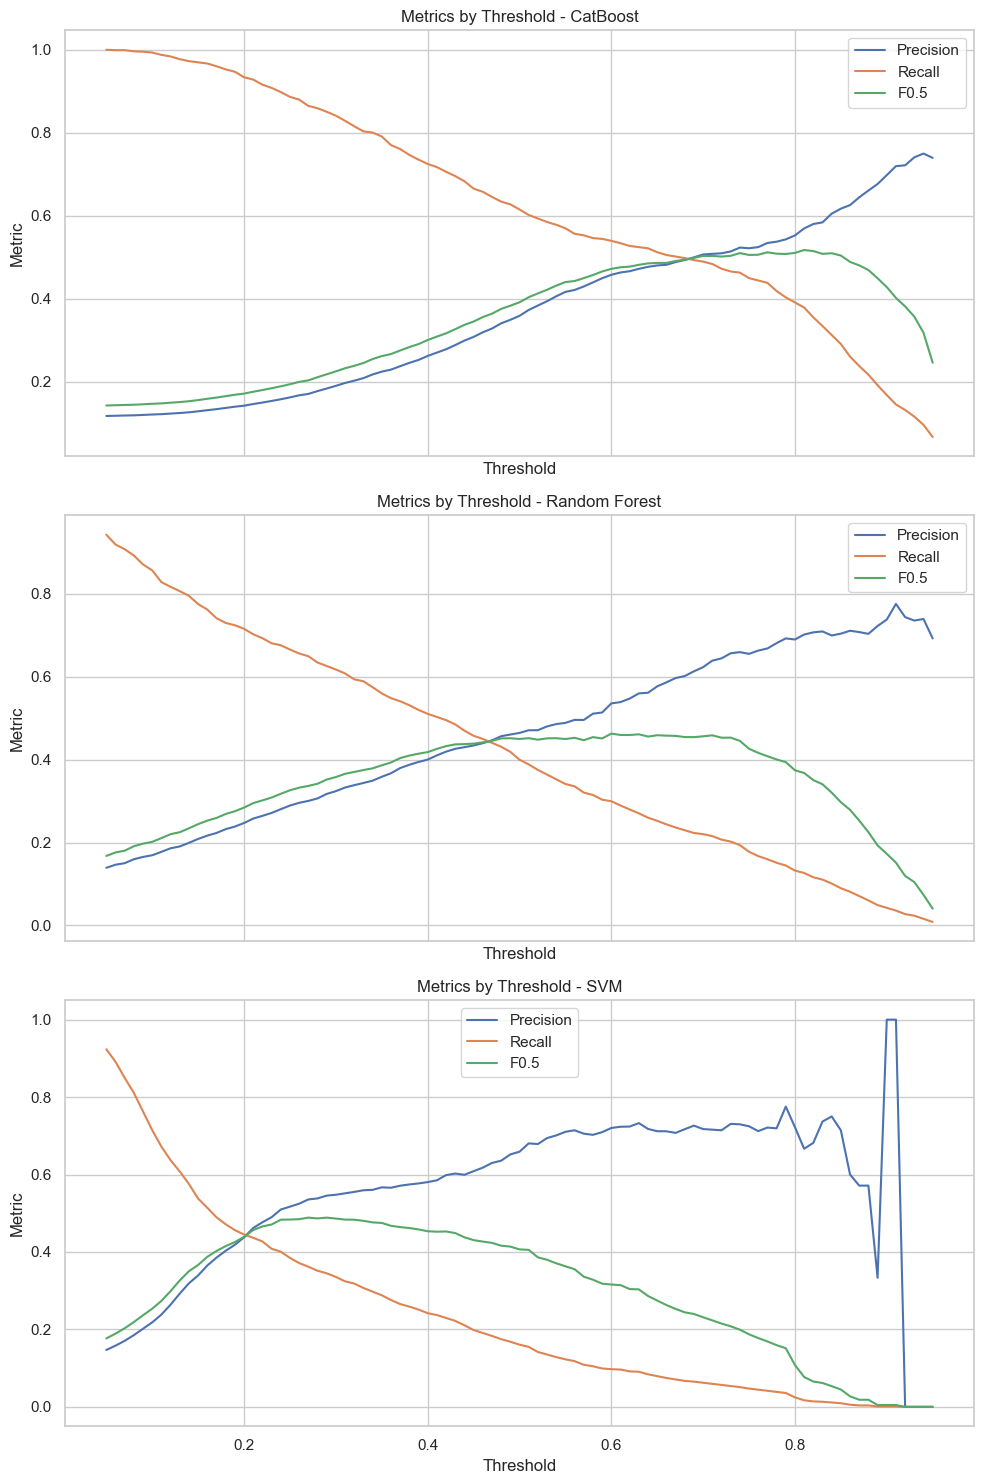

In [56]:
# Metrics charts by thresholds
fig, axes = plt.subplots(
    nrows=len(models_to_evaluate),
    ncols=1,
    figsize=(10, 5 * len(models_to_evaluate)),
    sharex=True
)

for ax, model_name in zip(axes, models_to_evaluate.keys()):
    df_model = threshold_results[threshold_results["model"] == model_name]
    
    ax.plot(df_model["threshold"], df_model["precision"], label="Precision")
    ax.plot(df_model["threshold"], df_model["recall"], label="Recall")
    ax.plot(df_model["threshold"], df_model["f0_5"], label="F0.5")
    
    ax.set_title(f"Metrics by Threshold - {model_name}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

The Precision-Recall curves of the three most promising models were evaluated: CatBoost, Random Forest and SVM.

The Precision-Recall curve shows that all models perform above the positive-class baseline, whose average rate is approximately 11.7%. This indicates that the models can rank customers with higher subscription propensity better than a random classification in this imbalanced dataset.

Among the evaluated models, CatBoost achieved the highest PR-AUC, approximately 0.453. This indicates that, considering different thresholds, it has the best overall ability to separate customers with higher and lower subscription propensity.

Next, Precision, Recall and F0.5 were evaluated at different thresholds. Since the problem gives more weight to reducing false positives, the F0.5-score was used to choose a threshold more suitable than the default value of 0.5.

The best threshold for CatBoost was approximately 0.81, resulting in precision of 0.57, recall of 0.38 and F0.5-score of 0.52. This was the best F0.5-score among the evaluated models.

Random Forest had higher precision at its best threshold, but lower recall. This indicates a model that makes fewer mistakes when predicting positives, but fails to identify a larger share of customers who would actually subscribe.

SVM also had good precision, but its F0.5-score was below CatBoost.

Based on this analysis, CatBoost proved to be the best-performing model at this stage, because it achieved both the highest PR-AUC and the best F0.5-score after threshold adjustment.


### 2.6.5 Evaluation of Metrics and Confusion Matrix at the Ideal Threshold


In [57]:

# Best thresholds found
best_threshold_dict = {
    "CatBoost": 0.81,
    "SVM": 0.27,
    "Random Forest": 0.66
}

# Calculate metrics based on thresholds
def evaluate_with_threshold(model_name, model_, X_test, y_test, threshold):
    y_proba = model_.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "modelo": model_name,
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f0_5": fbeta_score(y_test, y_pred, beta=0.5, zero_division=0),
        "qtd_preditos_positivos": y_pred.sum()
    }
    
    return metrics, y_pred, y_proba

In [58]:
# Evaluated models
models_threshold = {
    "CatBoost": models["CatBoost"],
    "Random Forest": models["Random Forest"],
    "SVM": models["SVM"]
}

results_threshold = {}
metrics_threshold = []

# For each model, calculate the metrics at the best threshold
for name, model_ in models_threshold.items():
    metrics, y_pred_thr, y_proba = evaluate_with_threshold(
        model_name=name,
        model_=model_,
        X_test=X_test,
        y_test=y_test,
        threshold=best_threshold_dict[name]
    )
    
    metrics_threshold.append(metrics)
    
    results_threshold[name] = {
        "y_pred": y_pred_thr,
        "y_proba": y_proba
    }

metrics_threshold = pd.DataFrame(metrics_threshold).sort_values(
    by="f0_5",
    ascending=False
)

metrics_threshold

,modelo,threshold,precision,recall,f0_5,qtd_preditos_positivos
0,CatBoost,0.8100,0.5696,0.3790,0.5176,704
2,SVM,0.2700,0.5357,0.3620,0.4888,715
1,Random Forest,0.6600,0.5839,0.2467,0.4585,447


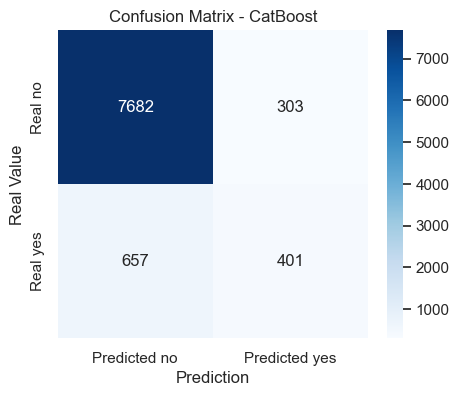

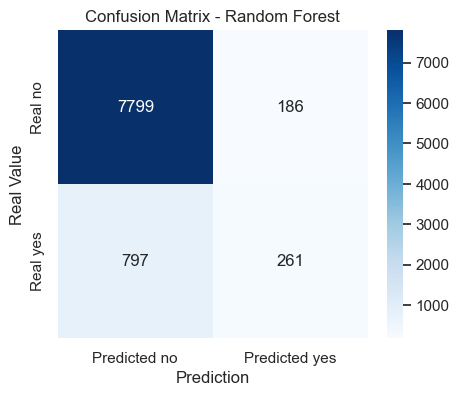

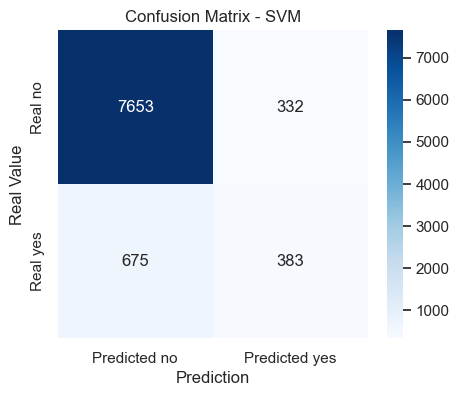

In [59]:

# Confusion matrix of each model at the best threshold
for name in models_threshold.keys():
    y_pred_thr = results_threshold[name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred_thr)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted no", "Predicted yes"],
        yticklabels=["Real no", "Real yes"]
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Prediction")
    plt.ylabel("Real Value")
    plt.show()

In [60]:
# Classification report of the models at the best threshold
for name in models_threshold.keys():
    print("=" * 80)
    print(f"Model: {name}")
    print(f"Threshold: {best_threshold_dict[name]}")
    print(classification_report(
        y_test,
        results_threshold[name]["y_pred"],
        zero_division=0
    ))

Model: CatBoost
Threshold: 0.81
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.57      0.38      0.46      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.67      0.70      9043
weighted avg       0.88      0.89      0.88      9043

Model: Random Forest
Threshold: 0.66
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.58      0.25      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.61      0.64      9043
weighted avg       0.87      0.89      0.87      9043

Model: SVM
Threshold: 0.27
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.54      0.36      0.43      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.6

`CatBoost`, with threshold 0.81, showed the best balance. The model reached 57% precision for the positive class and 38% recall, identifying 401 out of the 1,058 customers who actually subscribed, with 303 false positives. This was the best F0.5 result among the evaluated models.

`Random Forest`, with threshold 0.66, was the most conservative model. It had similar precision, 58%, but lower recall, 26%. This means it generated fewer false positives, only 194, but failed to identify more positive customers, classifying 788 subscribing customers as negative.

`SVM`, with threshold 0.27, had precision of 54% and recall of 36%. Its behavior was close to CatBoost in terms of recall, but with more false positives and lower F0.5.

Therefore, considering the objective of reducing false positives without losing too much ability to identify customers with higher subscription propensity, `CatBoost` will be selected as the main model for the next steps.


### 2.6.6 Hyperparameter Tuning - CatBoost

The optimization will be performed using cross-validation only on the training set. The metric chosen for the search will be `average_precision`, equivalent to PR-AUC, because it is more appropriate for imbalanced datasets.

After selecting the best hyperparameters, the model will be evaluated on the test set and the threshold will be optimized again based on the F0.5-score.


In [61]:

# Defining the Optuna study objective function
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "border_count": trial.suggest_categorical("border_count", [64, 128, 254]),
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "auto_class_weights": "Balanced",
        "random_seed": 42,
        "verbose": False,
        "allow_writing_files": False
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    pr_auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        train_pool = Pool(
            X_tr,
            y_tr,
            cat_features=categorical_features_model
        )

        val_pool = Pool(
            X_val,
            y_val,
            cat_features=categorical_features_model
        )

        model = CatBoostClassifier(**params)

        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=50,
            use_best_model=True
        )

        y_val_proba = model.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, y_val_proba)

        pr_auc_scores.append(pr_auc)

    return np.mean(pr_auc_scores)

In [99]:
# Running the study
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    study_name="catboost_pr_auc_optimization",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

[I 2026-07-08 20:08:51,631] A new study created in memory with name: catboost_pr_auc_optimization


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-08 20:09:20,814] Trial 0 finished with value: 0.43290139702727926 and parameters: {'iterations': 562, 'learning_rate': 0.13125830316209655, 'depth': 7, 'l2_leaf_reg': 3.968793330444372, 'random_strength': 0.864491338167939, 'bagging_temperature': 0.3119890406724053, 'border_count': 128}. Best is trial 0 with value: 0.43290139702727926.
[I 2026-07-08 20:13:33,158] Trial 1 finished with value: 0.43439726456212674 and parameters: {'iterations': 796, 'learning_rate': 0.010573268083515799, 'depth': 8, 'l2_leaf_reg': 6.798962421591129, 'random_strength': 1.1404616423235534, 'bagging_temperature': 0.36364993441420124, 'border_count': 254}. Best is trial 1 with value: 0.43439726456212674.
[I 2026-07-08 20:17:08,889] Trial 2 finished with value: 0.43470862490965695 and parameters: {'iterations': 602, 'learning_rate': 0.022004527434741072, 'depth': 7, 'l2_leaf_reg': 1.3787764619353768, 'random_strength': 1.5315087778225691, 'bagging_temperature': 0.7327236865873834, 'border_count': 12

In [100]:
print("Best mean PR-AUC:")
print(study.best_value)

print("\nBest hyperparameters:")
print(study.best_params)

Best mean PR-AUC:
0.4375808408003195

Best hyperparameters:
{'iterations': 457, 'learning_rate': 0.05039520254130886, 'depth': 7, 'l2_leaf_reg': 5.824943537868987, 'random_strength': 2.4495918717279235, 'bagging_temperature': 1.7588366336578478, 'border_count': 254}


In [101]:
optuna_results = study.trials_dataframe()
optuna_results.sort_values("value", ascending=False).head()

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_border_count,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
12,12,0.4376,2026-07-08 20:35:35.712601,2026-07-08 20:37:35.125764,0 days 00:01:59.413163,1.7588,254,7,457,5.8249,0.0504,2.4496,COMPLETE
28,28,0.4371,2026-07-08 20:54:49.079278,2026-07-08 20:56:05.014281,0 days 00:01:15.935003,1.4162,254,6,624,4.4013,0.0500,3.3816,COMPLETE
24,24,0.4371,2026-07-08 20:51:00.817942,2026-07-08 20:52:18.157259,0 days 00:01:17.339317,1.7238,254,8,372,4.6524,0.0470,3.6469,COMPLETE
30,30,0.4364,2026-07-08 20:57:11.348817,2026-07-08 20:58:57.526625,0 days 00:01:46.177808,1.8164,254,6,537,3.9672,0.0297,2.6172,COMPLETE
31,31,0.4363,2026-07-08 20:58:57.529317,2026-07-08 21:00:47.360778,0 days 00:01:49.831461,1.8151,254,6,573,4.1215,0.0294,2.5950,COMPLETE


In [102]:
# Training the model with the best hyperparameters
best_params = study.best_params.copy()

best_params.update({
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "auto_class_weights": "Balanced",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False
})

best_catboost = CatBoostClassifier(**best_params)

best_catboost.fit(
    X_train,
    y_train,
    cat_features=categorical_features_model
)

CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bagging_temperature=1.7588366336578478, border_count=254, depth=7, eval_metric='PRAUC', iterations=457, l2_leaf_reg=5.824943537868987, learning_rate=0.05039520254130886, loss_function='Logloss', random_seed=42, random_strength=2.4495918717279235, verbose=False)

In [103]:
# Evaluating the tuned model on the test data
y_proba_tuned = best_catboost.predict_proba(X_test)[:, 1]

catboost_tuned_metrics_05 = {
    "model": "CatBoost Tuned - threshold 0.5",
    "threshold": 0.5,
    "precision": precision_score(y_test, (y_proba_tuned >= 0.5).astype(int), zero_division=0),
    "recall": recall_score(y_test, (y_proba_tuned >= 0.5).astype(int), zero_division=0),
    "f0_5": fbeta_score(y_test, (y_proba_tuned >= 0.5).astype(int), beta=0.5, zero_division=0),
    "pr_auc": average_precision_score(y_test, y_proba_tuned),
    "brier_score": brier_score_loss(y_test, y_proba_tuned),
    "log_loss": log_loss(y_test, y_proba_tuned)
}

catboost_tuned_metrics_05

{'model': 'CatBoost Tuned - threshold 0.5',
 'threshold': 0.5,
 'precision': 0.37231638418079094,
 'recall': 0.6228733459357277,
 'f0_5': 0.4048906365200295,
 'pr_auc': 0.4523471837539898,
 'brier_score': 0.15065153382893423,
 'log_loss': 0.4809744328869133}

In [104]:
# Recalculating the best threshold with the tuned hyperparameters
threshold_grid = np.arange(0.05, 0.96, 0.01)

threshold_results_tuned = []

for threshold in threshold_grid:
    y_pred_threshold = (y_proba_tuned >= threshold).astype(int)

    threshold_results_tuned.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f0_5": fbeta_score(y_test, y_pred_threshold, beta=0.5, zero_division=0),
        "total_predicted_positives": y_pred_threshold.sum()
    })

threshold_results_tuned = pd.DataFrame(threshold_results_tuned)

best_threshold_tuned = (
    threshold_results_tuned
    .sort_values("f0_5", ascending=False)
    .head(1)
)

best_threshold_tuned

,threshold,precision,recall,f0_5,total_predicted_positives
79,0.8400,0.6077,0.3147,0.5123,548


In [105]:
# Final metrics with the tuned model and best threshold
best_threshold = best_threshold_tuned["threshold"].iloc[0]

y_pred_tuned = (y_proba_tuned >= best_threshold).astype(int)

catboost_tuned_metrics = {
    "model": "CatBoost Tuned",
    "threshold": best_threshold,
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f0_5": fbeta_score(y_test, y_pred_tuned, beta=0.5, zero_division=0),
    "pr_auc": average_precision_score(y_test, y_proba_tuned),
    "brier_score": brier_score_loss(y_test, y_proba_tuned),
    "log_loss": log_loss(y_test, y_proba_tuned),
    "total_predicted_positives": y_pred_tuned.sum()
}

catboost_tuned_metrics

{'model': 'CatBoost Tuned',
 'threshold': np.float64(0.8400000000000002),
 'precision': 0.6076642335766423,
 'recall': 0.31474480151228734,
 'f0_5': 0.5123076923076924,
 'pr_auc': 0.4523471837539898,
 'brier_score': 0.15065153382893423,
 'log_loss': 0.4809744328869133,
 'total_predicted_positives': np.int64(548)}

In [106]:
# Comparison: base CatBoost with best threshold vs tuned CatBoost with best threshold
catboost_base_result = {
    "model": "CatBoost Base",
    "threshold": 0.81,
    "precision": 0.5696,
    "recall": 0.3790,
    "f0_5": 0.5176,
    "pr_auc": 0.4533,
    "brier_score": 0.1512,
    "log_loss": 0.4824,
    "total_predicted_positives": 704
}

comparison_catboost = pd.DataFrame([
    catboost_base_result,
    catboost_tuned_metrics
])

comparison_catboost

,model,threshold,precision,recall,f0_5,pr_auc,brier_score,log_loss,total_predicted_positives
0,CatBoost Base,0.8100,0.5696,0.3790,0.5176,0.4533,0.1512,0.4824,704
1,CatBoost Tuned,0.8400,0.6077,0.3147,0.5123,0.4523,0.1507,0.4810,548


In [107]:
results_threshold["CatBoost Tuned"] = {}
results_threshold["CatBoost Tuned"]["y_pred"] = y_pred_tuned
results_threshold["CatBoost Tuned"]["y_proba"] = y_proba_tuned

In [108]:
results_threshold

{'CatBoost': {'y_pred': array([0, 0, 0, ..., 0, 1, 0], shape=(9043,)),
  'y_proba': array([0.11150097, 0.17415554, 0.21343373, ..., 0.33900626, 0.83973889,
         0.64071423], shape=(9043,))},
 'Random Forest': {'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(9043,)),
  'y_proba': array([0.02      , 0.02333333, 0.09666667, ..., 0.07      , 0.36      ,
         0.14666667], shape=(9043,))},
 'SVM': {'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(9043,)),
  'y_proba': array([0.01555392, 0.02708415, 0.03370671, ..., 0.09519474, 0.12957134,
         0.06651396], shape=(9043,))},
 'CatBoost Tuned': {'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(9043,)),
  'y_proba': array([0.12670533, 0.19186024, 0.19885399, ..., 0.35260716, 0.79022499,
         0.68417775], shape=(9043,))}}

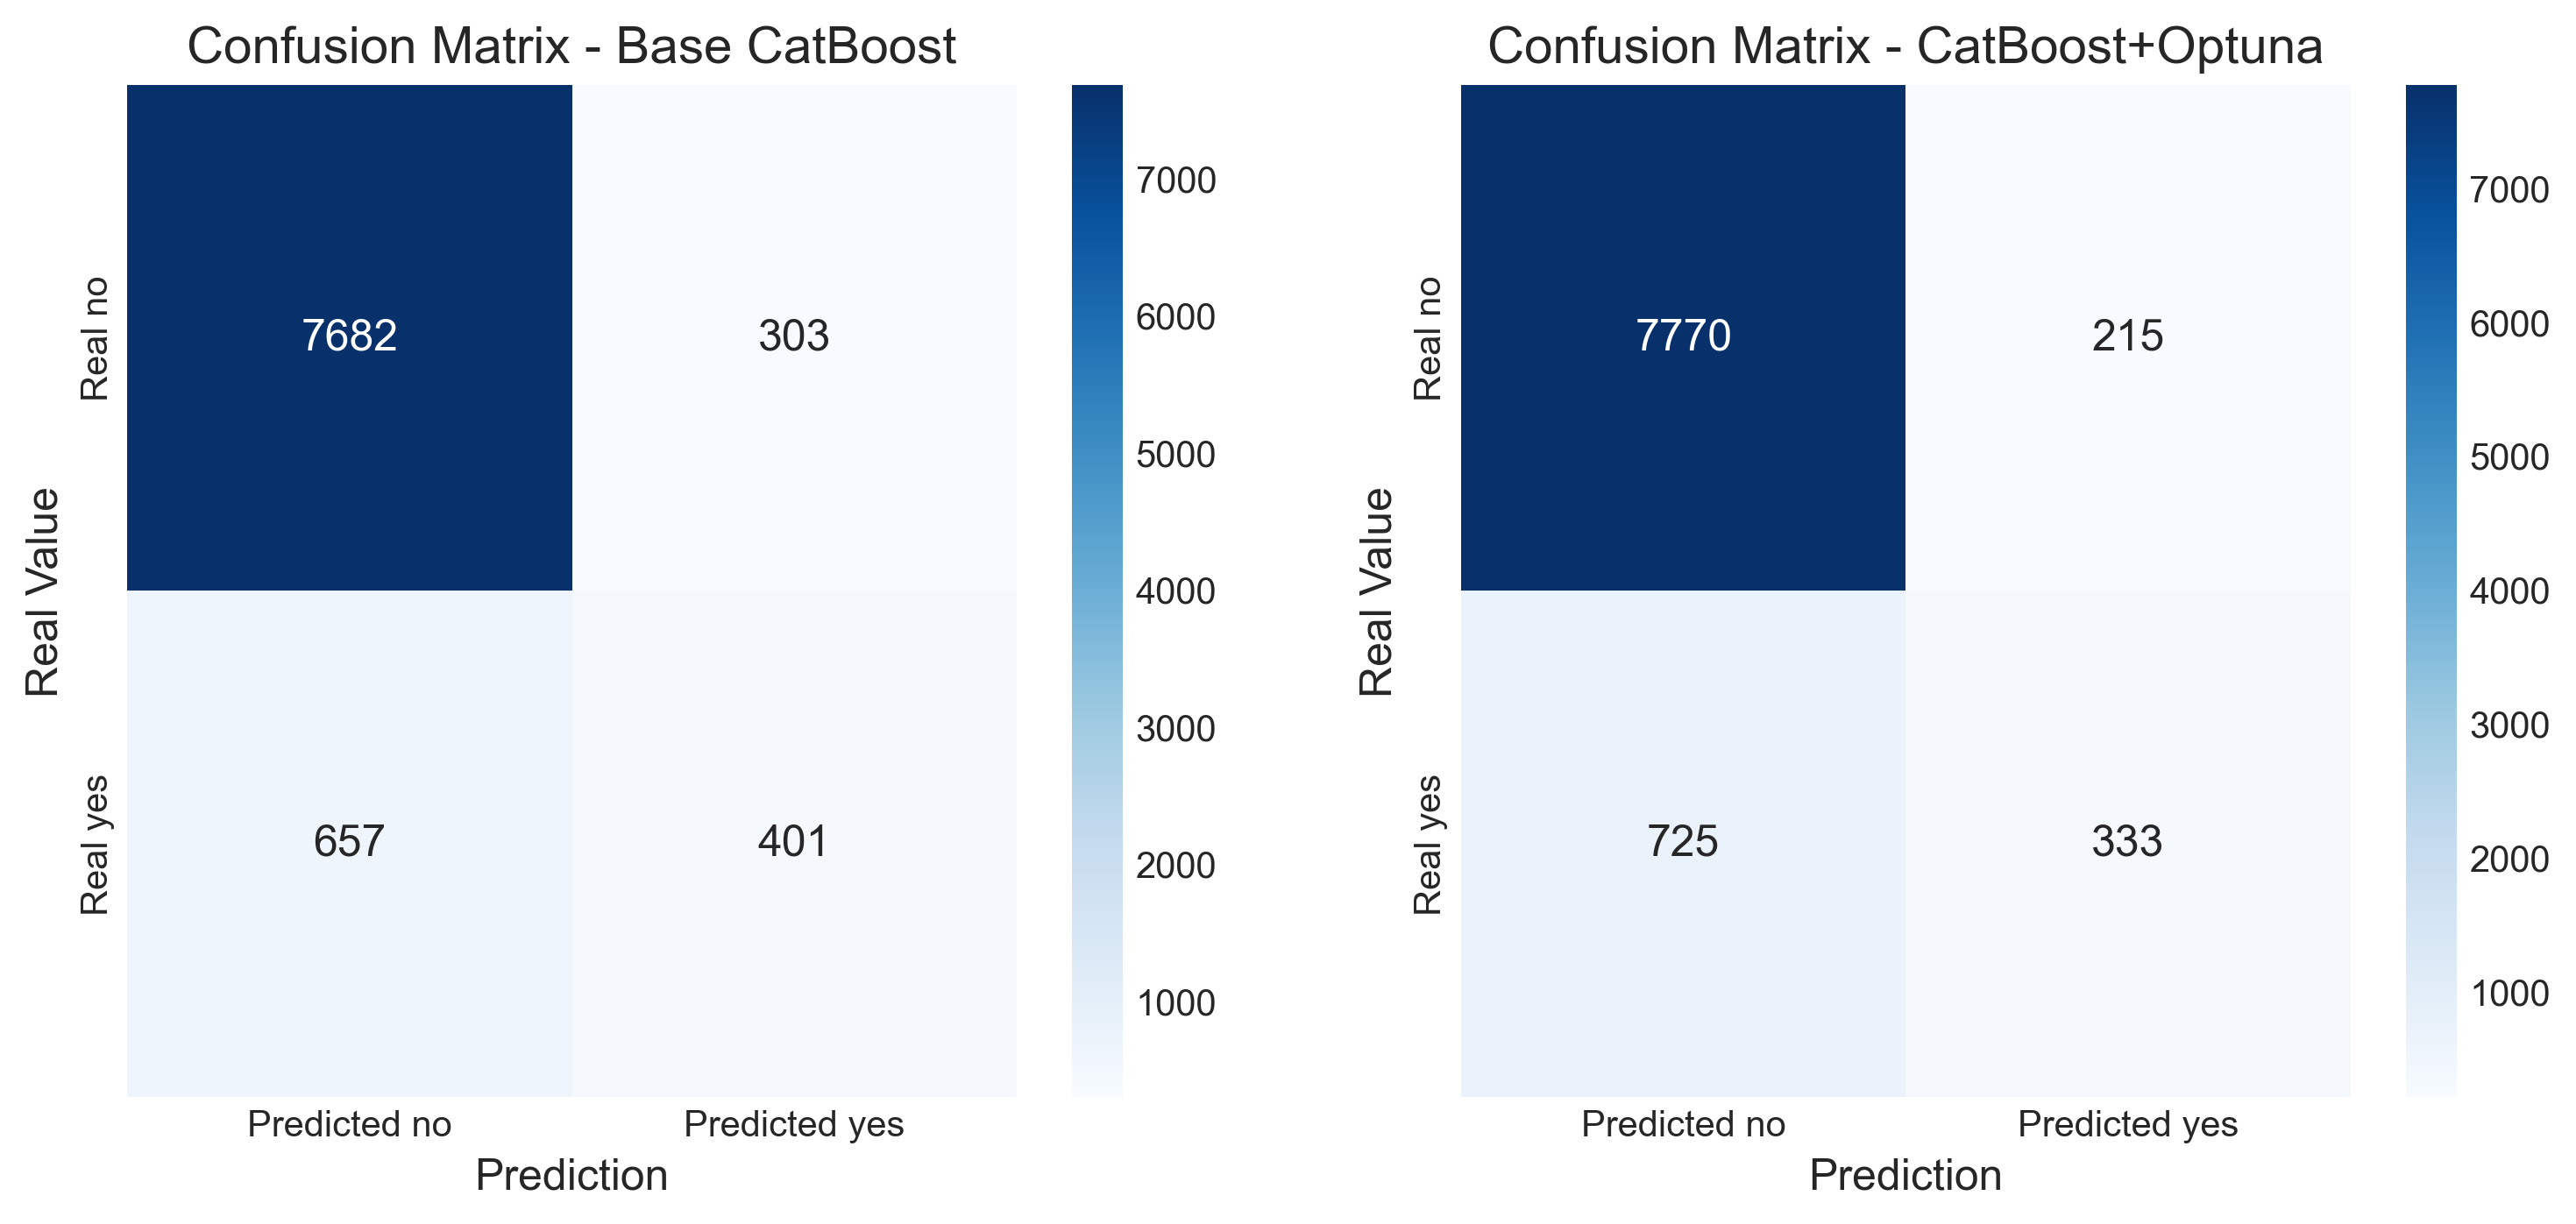

In [117]:
# Confusion matrix of each model at the best threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_thr_catboost = results_threshold["CatBoost"]["y_pred"]
cm_catboost = confusion_matrix(y_test, y_pred_thr_catboost)

y_pred_thr_catboost_optuna = results_threshold["CatBoost Tuned"]["y_pred"]
cm_catboost_tuned = confusion_matrix(y_test, y_pred_thr_catboost_optuna)

sns.heatmap(
            cm_catboost,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Predicted no", "Predicted yes"],
            yticklabels=["Real no", "Real yes"],
            ax=axes[0]
            )
axes[0].set_title(f"Confusion Matrix - Base CatBoost")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Real Value") 

sns.heatmap(
            cm_catboost_tuned,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Predicted no", "Predicted yes"],
            yticklabels=["Real no", "Real yes"],
            ax=axes[1]
            )
axes[1].set_title(f"Confusion Matrix - CatBoost+Optuna")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Real Value")

plt.show()


The CatBoost model optimized with Optuna became more conservative than the base model.

It increased Precision from 0.5696 to 0.6077 and reduced false positives from 303 to 215. This means that the tuned model is more selective when predicting the positive class.

However, this improvement came at the cost of lower Recall, which decreased from 0.3790 to 0.3147. The number of true positives also decreased from 401 to 333, while false negatives increased from 657 to 725.

The F0.5-score was slightly lower for the tuned model, decreasing from 0.5176 to 0.5123. PR-AUC also decreased slightly, from 0.4533 to 0.4523.

Although Brier Score and Log Loss improved marginally, from 0.1512 to 0.1507 and from 0.4824 to 0.4810 respectively, these gains were not large enough to justify replacing the base model.

Therefore, the tuned model can be seen as a more conservative alternative, suitable if the business wants a smaller and more precise contact list. However, considering the overall balance between Precision, Recall, F0.5-score and true positives captured, the base CatBoost remains the preferred model for the next steps.

### 2.6.7 Calibration

First, I will evaluate the calibration of the base CatBoost model through metrics and the calibration plot. The calibration curve compares the model's predicted probabilities with the observed real frequency. An ideally calibrated model would be one in which, if we have x% positive examples in the dataset, it classifies an example as positive x% of the time; in other words, in the calibration curve, the result would be close to the diagonal line.

The technique I will use for calibration is Venn-Abers. Instead of returning only a point probability for each class, it produces a probability interval that represents prediction uncertainty. Basically, the intuition behind the method is to consider that the predicted point belongs to the positive class or to the negative class, and then apply isotonic regression to each case, obtaining two estimated probabilities. As a result, the true probability of the positive class is estimated as belonging to the interval `(p0, p1)`.


In [73]:
# Probabilities from the base CatBoost
catboost_base = models["CatBoost"]

y_proba_raw = catboost_base.predict_proba(X_test)[:, 1]

raw_calibration_metrics = {
    "model": "Base CatBoost - no calibration",
    "pr_auc": average_precision_score(y_test, y_proba_raw),
    "brier_score": brier_score_loss(y_test, y_proba_raw),
    "log_loss": log_loss(y_test, y_proba_raw)
}

raw_calibration_metrics

{'model': 'Base CatBoost - no calibration',
 'pr_auc': 0.45332157159021574,
 'brier_score': 0.15124896294091006,
 'log_loss': 0.4823576625624185}

<Figure size 600x500 with 0 Axes>

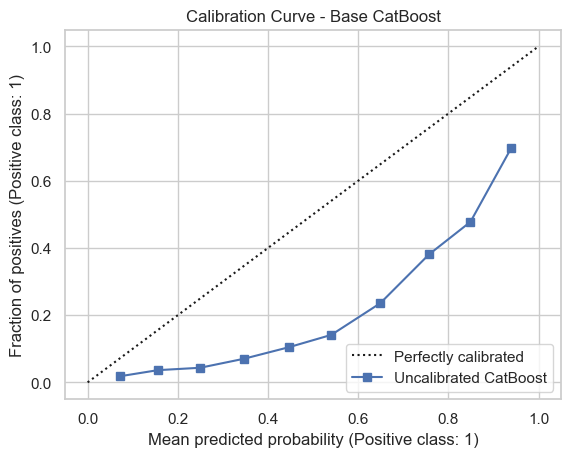

In [74]:
# Calibration chart of the base CatBoost
plt.figure(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_raw,
    n_bins=10,
    name="Uncalibrated CatBoost"
)

plt.title("Calibration Curve - Base CatBoost")
plt.grid(True)
plt.show()

The initial calibration is quite far from ideal. The average probability predicted by the model for the positive class is always above the fraction of positives in the dataset. For example, the model predicts an average probability of 60% when 20% of the examples belong to the positive class.


In [75]:
# Calibration with Venn-Abers

# Copies of the datasets for calibration
X_train_va = X_train.copy()
X_calib_va = X_calib.copy()
X_test_va = X_test.copy()

# Encoder only to transform categories into numerical IDs
ordinal_encoder_va = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit only on the training set
X_train_va[categorical_features_model] = ordinal_encoder_va.fit_transform(
    X_train_va[categorical_features_model].astype(str)
)

# Transform on calibration and test sets
X_calib_va[categorical_features_model] = ordinal_encoder_va.transform(
    X_calib_va[categorical_features_model].astype(str)
)

X_test_va[categorical_features_model] = ordinal_encoder_va.transform(
    X_test_va[categorical_features_model].astype(str)
)

# Convert encoded categorical variables to int
for col in categorical_features_model:
    X_train_va[col] = X_train_va[col].astype(int)
    X_calib_va[col] = X_calib_va[col].astype(int)
    X_test_va[col] = X_test_va[col].astype(int)

In [76]:
# Identifying categorical feature indices
cat_feature_indices_va = [
    X_train_va.columns.get_loc(col)
    for col in categorical_features_model
]

cat_feature_indices_va

[1, 2, 3, 4, 6, 7, 8, 9, 12, 13]

In [77]:
# Defining a wrapper to use CatBoost with Venn-Abers
class CatBoostVAWrapper(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        cat_features=None
    ):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.loss_function = loss_function
        self.eval_metric = eval_metric
        self.auto_class_weights = auto_class_weights
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files
        self.cat_features = cat_features

    def fit(self, X, y):
        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            loss_function=self.loss_function,
            eval_metric=self.eval_metric,
            auto_class_weights=self.auto_class_weights,
            random_seed=self.random_seed,
            verbose=self.verbose,
            allow_writing_files=self.allow_writing_files
        )

        self.model_.fit(
            X,
            y,
            cat_features=list(self.cat_features) if self.cat_features is not None else None
        )

        self.classes_ = self.model_.classes_
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        return self.model_.predict(X)

In [78]:
# Calibrating CatBoost with Venn-Abers
catboost_for_va = CatBoostVAWrapper(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    cat_features=tuple(cat_feature_indices_va)
)

# Venn-Abers calibrator
va_calibrator = VennAbersCalibrator(
    estimator=catboost_for_va,
    inductive=True,
    random_state=42
)

# Fit using training + calibration set
va_calibrator.fit(
    X_train_va,
    y_train,
    X_calib=X_calib_va,
    y_calib=y_calib
)

,estimator,"CatBoostVAWra...8, 9, 12, 13))"
,random_state,42
,cv,None
,inductive,True
,n_splits,None
,train_proper_size,None
,shuffle,True
,stratify,None
,precision,None
,cv_ensemble,True
Name,Type,Value


In [79]:
# Uncalibrated probabilities from the base CatBoost
catboost_base = models["CatBoost"]
y_proba_raw = catboost_base.predict_proba(X_test)[:, 1]

# Probabilities calibrated with Venn-Abers
# The internal warning may occur; we validate the output afterwards.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    y_proba_va_full = va_calibrator.predict_proba(X_test_va)

# Validity check
print("Calibrated Probabilities - Shape:", y_proba_va_full.shape)
print("Amount of NaN:", np.isnan(y_proba_va_full).sum())
print("Amount of infinites:", np.isinf(y_proba_va_full).sum())

# If invalid values exist, stop execution
if not np.isfinite(y_proba_va_full).all():
    raise ValueError(
        "The calibrated probabilities contain NaN or infinites. "
        "It's not safe to proceed with the evaluation of the calibration."
    )

# Calibrated probability of the positive class
y_proba_va = y_proba_va_full[:, 1]

# Numerical safety for metrics such as log_loss
eps = 1e-15
y_proba_raw_clipped = np.clip(y_proba_raw, eps, 1 - eps)
y_proba_va_clipped = np.clip(y_proba_va, eps, 1 - eps)

Calibrated Probabilities - Shape: (9043, 2)
Amount of NaN: 0
Amount of infinites: 0


In [80]:
# Comparing calibration before and after Venn-Abers
calibration_comparison = pd.DataFrame([
    {
        "model": "Base CatBoost - No Calibration",
        "pr_auc": average_precision_score(y_test, y_proba_raw),
        "brier_score": brier_score_loss(y_test, y_proba_raw),
        "log_loss": log_loss(y_test, y_proba_raw_clipped)
    },
    {
        "model": "CatBoost + Venn-Abers",
        "pr_auc": average_precision_score(y_test, y_proba_va),
        "brier_score": brier_score_loss(y_test, y_proba_va),
        "log_loss": log_loss(y_test, y_proba_va_clipped)
    }
                                        ])

calibration_comparison

,model,pr_auc,brier_score,log_loss
0,Base CatBoost - No Calibration,0.4533,0.1512,0.4824
1,CatBoost + Venn-Abers,0.4360,0.0811,0.2838


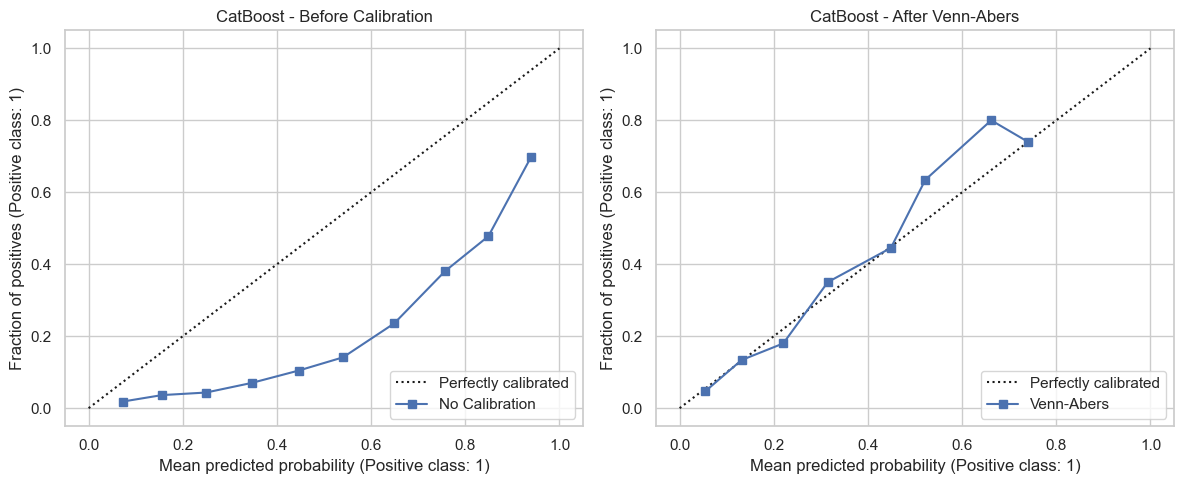

In [81]:
# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_raw,
    n_bins=10,
    name="No Calibration",
    ax=axes[0]
)

axes[0].set_title("CatBoost - Before Calibration")
axes[0].grid(True)

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_va,
    n_bins=10,
    name="Venn-Abers",
    ax=axes[1]
)

axes[1].set_title("CatBoost - After Venn-Abers")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Venn-Abers calibration significantly improved the model's ability to estimate probabilities. The second chart is much closer to the line that represents an ideal model than the chart of the model without calibration. I will calculate the best threshold again using the calibrated probabilities.


In [82]:
# Recalculating the best threshold after Venn-Abers
threshold_grid = np.arange(0.05, 0.96, 0.01)

threshold_results_va = []

for threshold in threshold_grid:
    y_pred_threshold = (y_proba_va >= threshold).astype(int)

    threshold_results_va.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f0_5": fbeta_score(y_test, y_pred_threshold, beta=0.5, zero_division=0),
        "total_predicted_positives": y_pred_threshold.sum()
    })

threshold_results_va = pd.DataFrame(threshold_results_va)

best_threshold_va = (
    threshold_results_va
    .sort_values("f0_5", ascending=False)
    .head(1)
)

best_threshold_va

,threshold,precision,recall,f0_5,total_predicted_positives
36,0.4100,0.5340,0.4159,0.5053,824


In [83]:
# Final metrics with Venn-Abers
threshold_va = best_threshold_va["threshold"].iloc[0]

y_pred_va = (y_proba_va >= threshold_va).astype(int)

catboost_va_metrics = {
    "model": "CatBoost + Venn-Abers",
    "threshold": threshold_va,
    "precision": precision_score(y_test, y_pred_va, zero_division=0),
    "recall": recall_score(y_test, y_pred_va, zero_division=0),
    "f0_5": fbeta_score(y_test, y_pred_va, beta=0.5, zero_division=0),
    "pr_auc": average_precision_score(y_test, y_proba_va),
    "brier_score": brier_score_loss(y_test, y_proba_va),
    "log_loss": log_loss(y_test, y_proba_va_clipped),
    "total_predicted_positives": y_pred_va.sum()
}

catboost_va_metrics

{'model': 'CatBoost + Venn-Abers',
 'threshold': np.float64(0.4100000000000001),
 'precision': 0.5339805825242718,
 'recall': 0.4158790170132325,
 'f0_5': 0.5052824988516307,
 'pr_auc': 0.4360296275615564,
 'brier_score': 0.08105976613337577,
 'log_loss': 0.28376317265748857,
 'total_predicted_positives': np.int64(824)}

In [118]:
# Comparison: base CatBoost vs calibrated CatBoost
catboost_base_final = {
    "model": "Base CatBoost ",
    "threshold": 0.81,
    "precision": 0.5696,
    "recall": 0.3790,
    "f0_5": 0.5176,
    "pr_auc": 0.4533,
    "brier_score": 0.1512,
    "log_loss": 0.4824,
    "total_predicted_positives": 704
}

comparison_final_calibration = pd.DataFrame([
    catboost_base_final,
    catboost_va_metrics
])

comparison_final_calibration

,model,threshold,precision,recall,f0_5,pr_auc,brier_score,log_loss,total_predicted_positives
0,Base CatBoost,0.8100,0.5696,0.3790,0.5176,0.4533,0.1512,0.4824,704
1,CatBoost + Venn-Abers,0.4100,0.5340,0.4159,0.5053,0.4360,0.0811,0.2838,824


In [85]:
# Comparison of confusion matrices

# Predictions from the base CatBoost
threshold_base = 0.81
y_pred_base = (y_proba_raw >= threshold_base).astype(int)

# Predictions from the calibrated CatBoost
threshold_va = 0.41
y_pred_va = (y_proba_va >= threshold_va).astype(int)

# Matrices
cm_base = confusion_matrix(y_test, y_pred_base)
cm_va = confusion_matrix(y_test, y_pred_va)

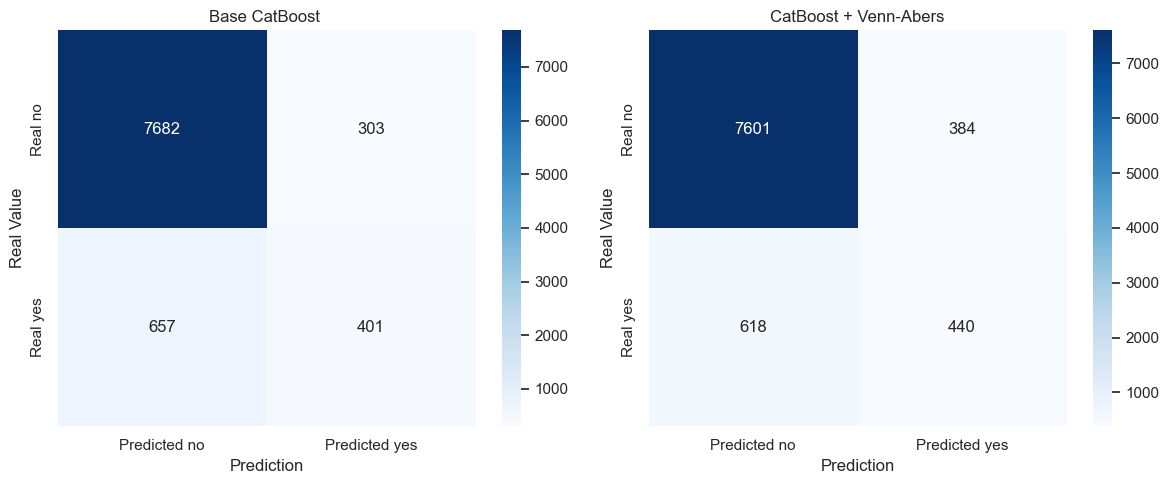

In [86]:
# Plotting the matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted no", "Predicted yes"],
    yticklabels=["Real no", "Real yes"],
    ax=axes[0]
)

axes[0].set_title("Base CatBoost ")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Real Value")

sns.heatmap(
    cm_va,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted no", "Predicted yes"],
    yticklabels=["Real no", "Real yes"],
    ax=axes[1]
)

axes[1].set_title("CatBoost + Venn-Abers")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Real Value")

plt.tight_layout()
plt.show()

Before calibration, the calibration curve indicated that the model was overestimating probabilities. The curve was below the diagonal, showing that for several predicted probability ranges, the real subscription rate was lower than the probability estimated by the model.

After applying Venn-Abers, the calibration curve became much closer to the diagonal, indicating better alignment between predicted probabilities and observed real frequencies.

This improvement also appears in the probabilistic metrics: the Brier Score dropped from 0.1512 to 0.0811 and Log Loss dropped from 0.4824 to 0.2838, nearly a 50% reduction.

This indicates that the calibrated probabilities became more reliable.

On the other hand, there was a small deterioration in ranking/classification metrics: PR-AUC, F0.5-score and Precision, while Recall improved.

In other words, calibration significantly improved probability quality, but slightly reduced the metrics associated with the positive class. However, the number of predicted positives increased, so the model is likely classifying more examples as false positives.

Since the objective of the study involves estimating reliable probabilities and associating risk/uncertainty with predictions, the model calibrated with Venn-Abers is more appropriate for probabilistic use and decision-making. The base model, on the other hand, had slightly better F0.5 performance.

For this study, I consider that the calibrated model performs better in terms of calculated probabilities, even if it is slightly worse in ranking examples. Ultimately, the choice between the two models would be a business decision. The difference in false positives may be justified by the ability to quantify model risk through better calibrated probabilities.


### 2.6.8 Feature Importance and Calibrated Explanations

To evaluate the importance of each variable for the model, I will use CatBoost feature importance. I will also use the `calibrated-explanations` library (https://github.com/Moffran/calibrated_explanations), which can generate explanations with calibrated probabilities and uncertainty intervals using Venn-Abers for classification. It has the `CalibratedExplainer` class, which receives a model and a calibration set, then explains specific records, with different importances for each variable depending on the evaluated record.


In [87]:
# Trained base CatBoost model
catboost_base = models["CatBoost"]

# Pool with training data and categorical variables
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features_model
)

# Native CatBoost feature importance
feature_importances = catboost_base.get_feature_importance(
    data=train_pool,
    type="PredictionValuesChange"
)

feature_importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importances
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df

,feature,importance
0,month,16.2125
1,balance,13.4798
2,poutcome,10.1743
3,contact,9.1096
4,job,8.1930
5,age,7.9414
6,day_period,7.0606
7,campaign,6.4633
8,marital,4.9948
9,pdays_since_previous_contact,4.8571


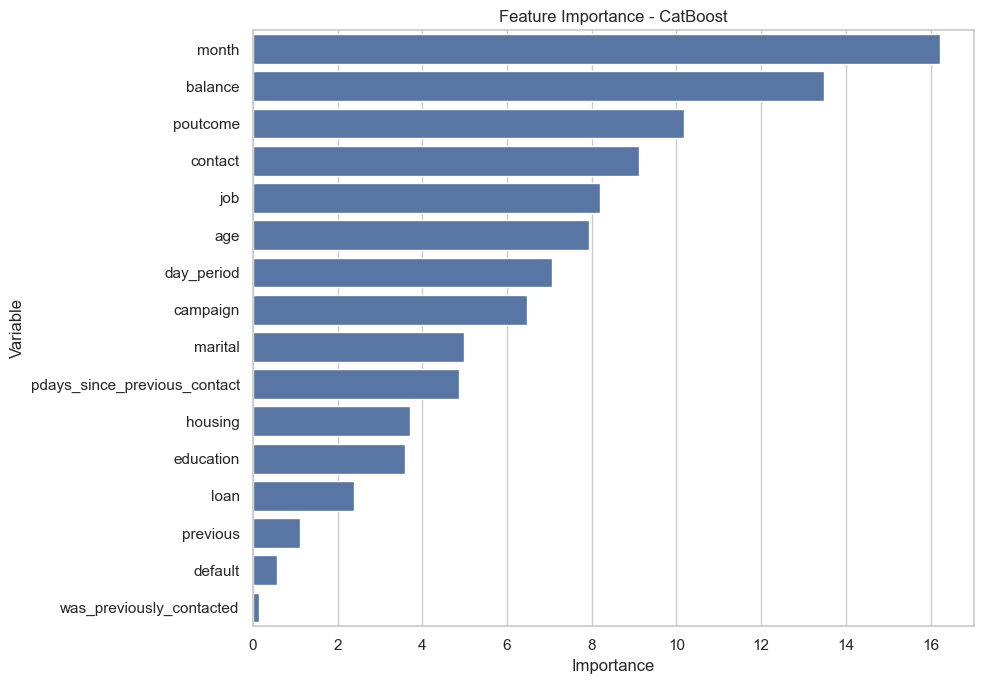

In [88]:
# Chart with CatBoost feature importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - CatBoost")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

The CatBoost Feature Importance analysis showed that the variables with the highest contribution to the predictions were `month`, `balance`, `poutcome`, `contact`, `job`, `age`, `day_period` and `campaign`.

This result is consistent with the exploratory analysis. Variables related to the campaign period, contact channel, previous campaign history and customer financial profile had already shown relevant relationship with the target variable.

The variable `month` appeared as the most important, suggesting that the period in which the contact occurred has strong influence on the model predictions. This may reflect seasonality or operational differences between campaigns carried out in different months.

The variable `balance` also showed high importance, indicating that the customer's average yearly balance contributes considerably to differentiating profiles with higher or lower subscription probability.

The variable `poutcome`, related to the result of the previous campaign, also appeared among the most important variables. This reinforces that the customer's previous interaction history is relevant information for prediction.

The variables `contact`, `job`, `age`, `day_period` and `campaign` also show relevant importance, indicating that both contact characteristics and customer characteristics influence the prediction.

On the other hand, variables such as `default`, `previous` and `was_previously_contacted` had low global importance in the final model. This does not mean they are irrelevant from a business perspective, but rather that, within the structure learned by CatBoost, they contributed less to the predictions. In other words, this result cannot be interpreted as a causal relationship. These values indicate which features contributed more to the model's predictive performance.

Now I will use the `calibrated-explanations` library to provide an example of how we can observe the importance of each feature for a specific prediction, with uncertainty intervals for each feature.


In [89]:
# Feature names in the same order as X_train_va
feature_names_va = X_train_va.columns.tolist()

# Categorical feature indices
cat_feature_indices_va = [
    X_train_va.columns.get_loc(col)
    for col in categorical_features_model
]

# Mapping OrdinalEncoder codes back to the original category names
categorical_labels_va = {}

for col in categorical_features_model:
    feature_idx = X_train_va.columns.get_loc(col)
    encoder_col_idx = categorical_features_model.index(col)
    
    categories = ordinal_encoder_va.categories_[encoder_col_idx]
    
    categorical_labels_va[feature_idx] = {
        int(code): str(label)
        for code, label in enumerate(categories)
    }
    
    # Category for unknown values in calibration/test, if they appear
    categorical_labels_va[feature_idx][-1] = "unknown_unseen_category"

In [90]:
# I will reuse the wrapper created for Venn-Abers
# (Calibrated Explanations uses Venn-Abers)
catboost_explainer_model = CatBoostVAWrapper(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    cat_features=tuple(cat_feature_indices_va)
                                            )

catboost_explainer_model.fit(X_train_va, y_train)

# Running CalibratedExplainer

explainer = CalibratedExplainer(
    catboost_explainer_model,
    X_calib_va,
    y_calib,
    mode="classification",
    feature_names=feature_names_va,
    categorical_features=cat_feature_indices_va,
    categorical_labels=categorical_labels_va,
    class_labels={
        0: "no",
        1: "yes"
                }
                                )

I decided to choose a positive example to explain using Calibrated Explanations:

In [91]:
# Probabilities calibrated via Venn-Abers
y_proba_va = va_calibrator.predict_proba(X_test_va)[:, 1]

# Threshold chosen after calibration
threshold_va = 0.41

# Indices predicted as positive
positive_indices = np.where(y_proba_va >= threshold_va)[0]

# Choose the first positive example
example_idx = positive_indices[0]

X_example = X_test_va.iloc[[example_idx]]
y_example_real = y_test.iloc[example_idx]
proba_example = y_proba_va[example_idx]

print("Index:", example_idx)
print("Real Class:", y_example_real)
print("Calibrated Probability:", proba_example)

Index: 7
Real Class: 1
Calibrated Probability: 0.7421875


In [92]:
factual_batch = explainer.explain_factual(X_example)
factual = factual_batch[0]

print("Calibrated Prediction:", factual.predict)
print("Prediction Interval:", factual.prediction_interval)

Calibrated Prediction: 0.7271095208780669
Prediction Interval: (np.float64(0.7037037014961243), np.float64(0.7894737124443054))


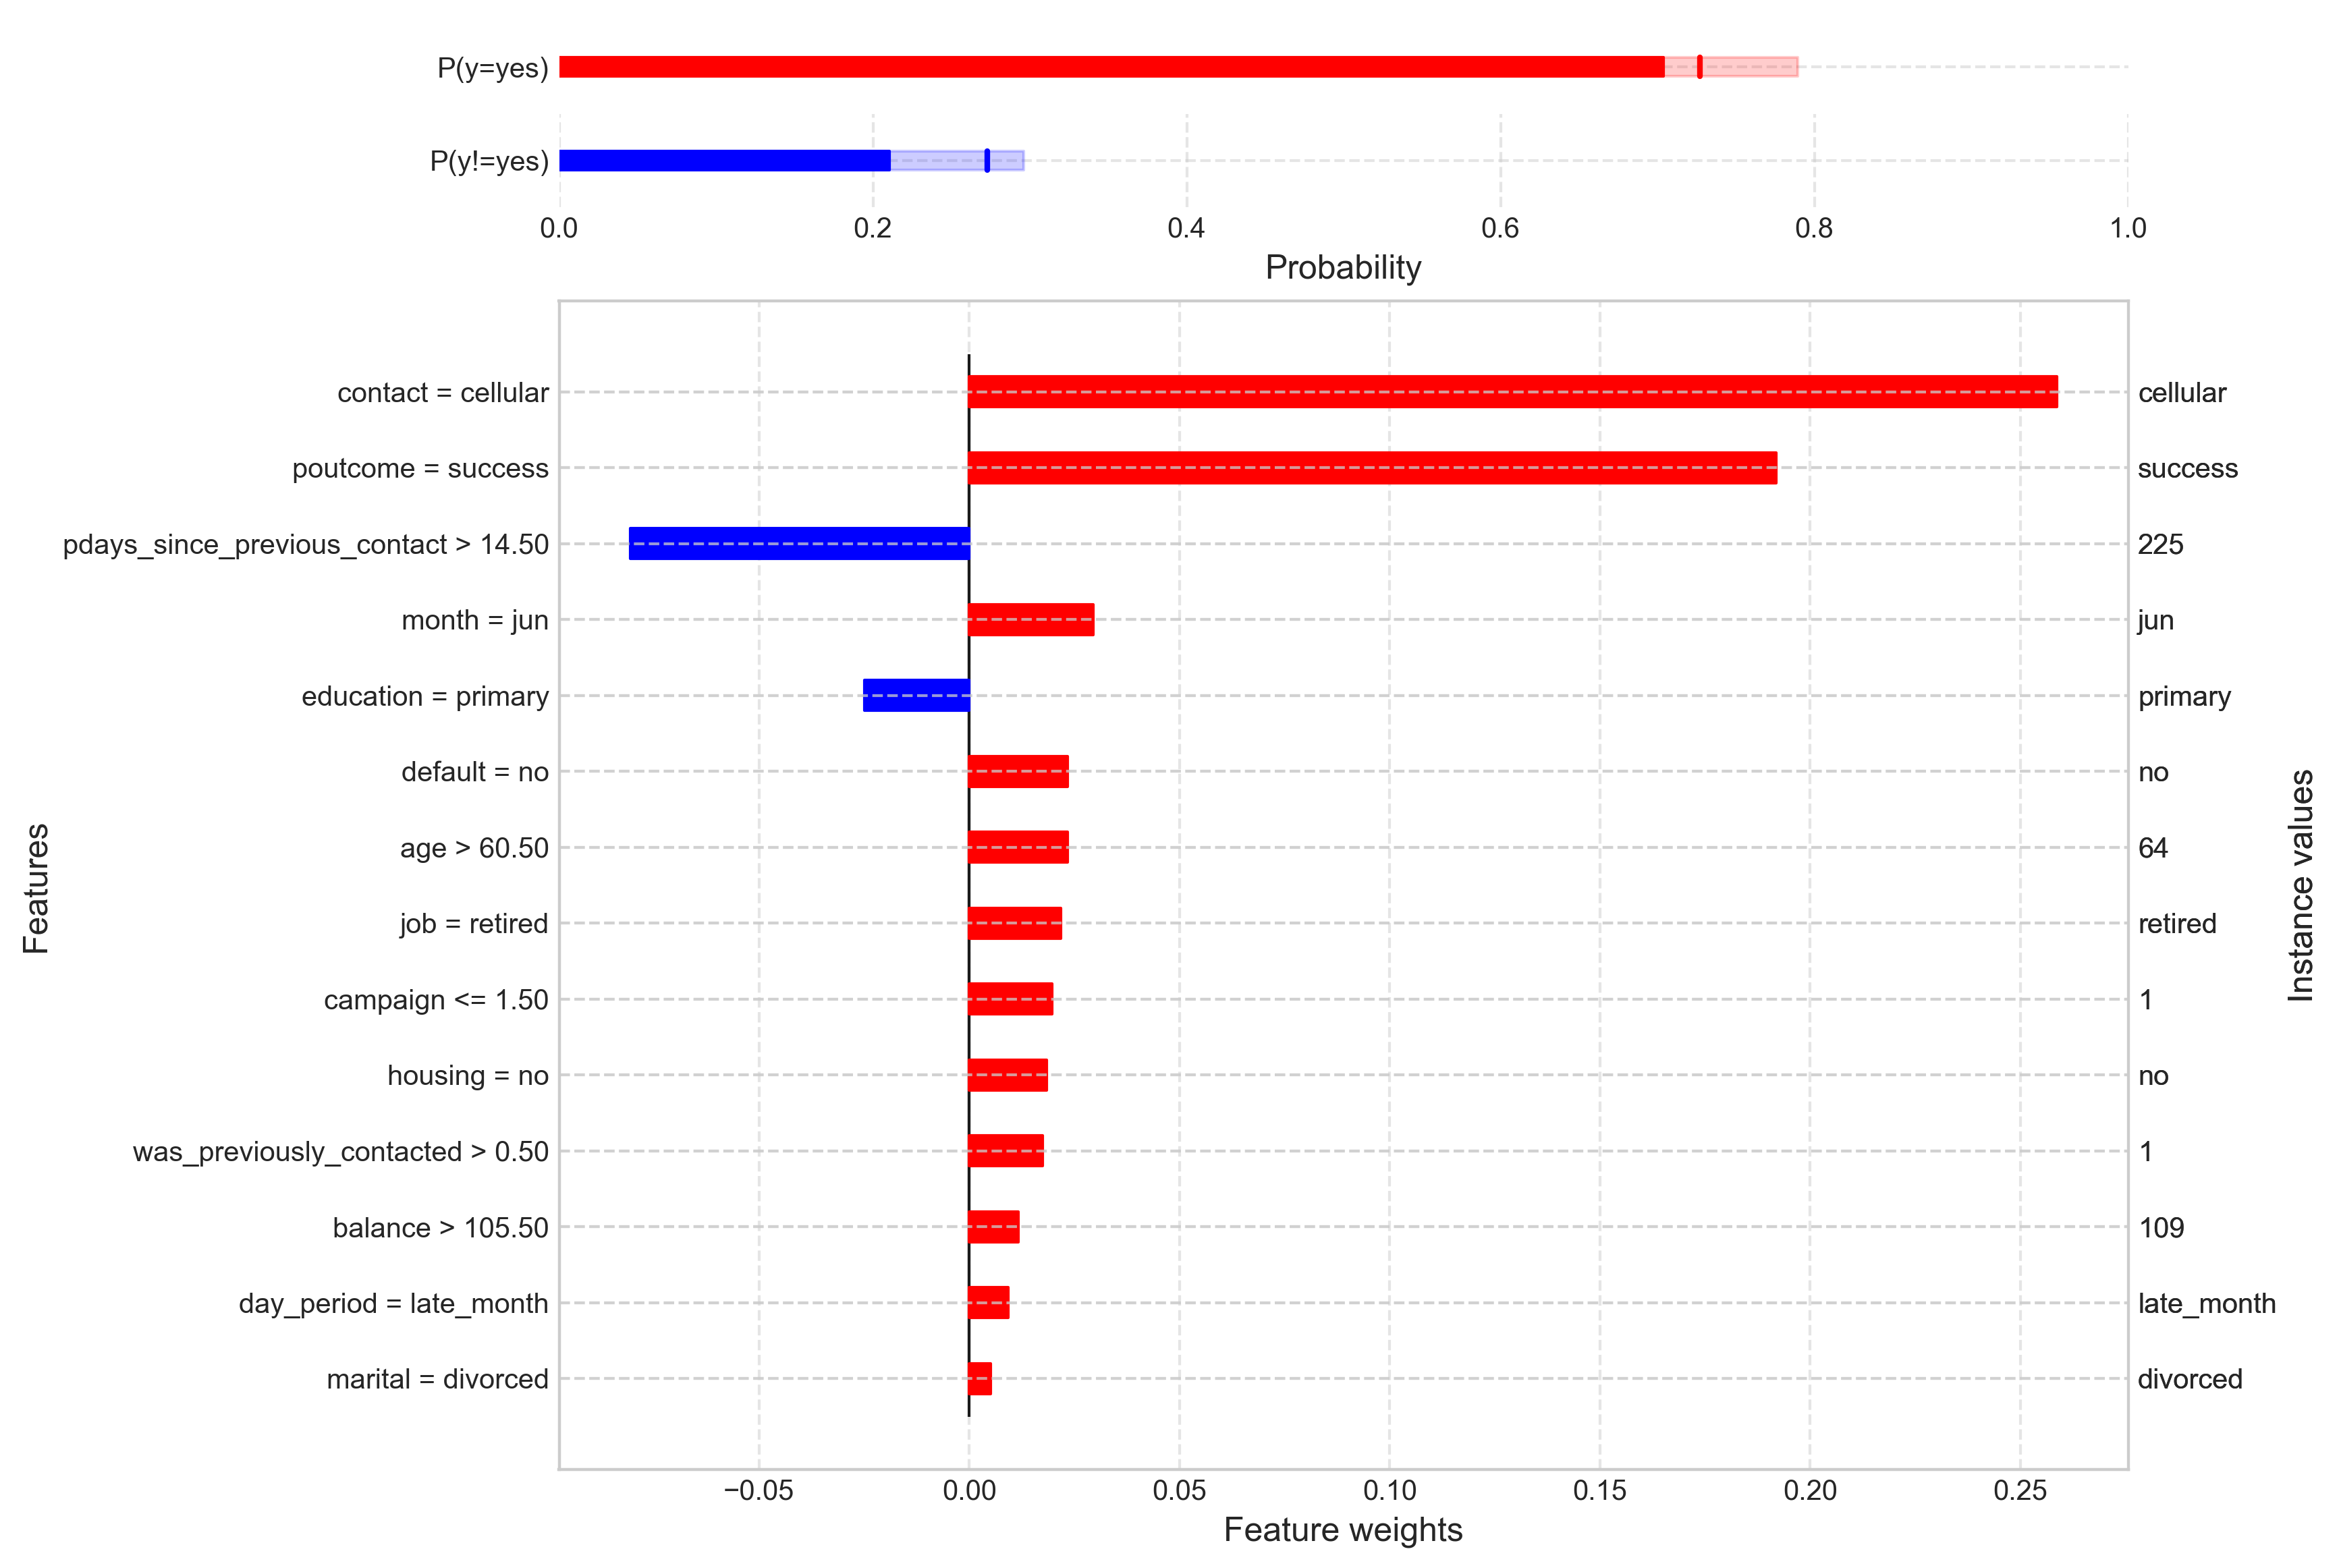

In [93]:
factual.plot()

Unlike global feature importance, this explanation shows which variables contributed most to the prediction of a specific customer.

The advantage of this approach is that the explanation is built on calibrated probabilities and accompanied by an uncertainty interval. Thus, besides knowing which variables pushed the prediction up or down, it is also possible to assess the degree of uncertainty associated with the prediction.

The red bars represent factors that increased the probability of the positive class, while the blue bars represent factors that reduced this probability.

In this case, the factors that contributed most positively were:

- `contact = cellular`;
- `poutcome = success`;
- `month = jun`;
- `default = no`;
- `age > 60.5`;
- `job = retired`;
- `campaign <= 1.5`;
- `housing = no`.

The factor with the largest negative contribution was `pdays_since_previous_contact > 14.5`, indicating that, for this specific observation, the time since the previous contact reduced the predicted probability of subscription. Again: this should not be interpreted as causal inference, but rather as the model's behavior for this specific case.

## 2.7 MLOps


To use the model in production, we need to save the artifacts and always use the same pipeline to ensure reproducibility. In addition, the model performance must be monitored and the model should be retrained when necessary.

A possible flow would be as follows: when receiving a new customer base, we apply the same transformations used during training, generate the calibrated probability of subscription and, after applying the best threshold found, rank the customer(s). Finally, the model output could contain:

- customer identifier(s);
- calibrated probability of subscription;
- prediction uncertainty interval;
- final predicted class;
- threshold used.

Based on the probabilities, customers can be segmented. For example:

- High probability of subscription and low risk;
- High probability of subscription and high risk;
- Low probability of subscription and low risk;
- Low probability of subscription and high risk.


The artifacts we would need to save are:

- The trained CatBoost model;
- The Venn-Abers calibrator;
- The encoder used for categorical variables;
- The list of features used;
- The list of categorical variables;
- The final threshold;
- The final model metrics, so that we can compare them when reevaluating the model performance.

These objects can be saved with `joblib` or `pickle`. For example:


In [94]:
model_artifacts = {
    "model": catboost_base,
    "venn_abers_calibrator": va_calibrator,
    "ordinal_encoder": ordinal_encoder_va,
    "features": X_train.columns.tolist(),
    "categorical_features": categorical_features_model,
    "threshold": 0.41,
    "metrics": catboost_va_metrics
                    }

joblib.dump(model_artifacts, "./Artifacts/catboost_venn_abers_artifacts.pkl")

['./Artifacts/catboost_venn_abers_artifacts.pkl']

To load the artifacts:


In [95]:

model_artifacts = joblib.load("./Artifacts/catboost_venn_abers_artifacts.pkl")

model = model_artifacts["model"]
calibrator = model_artifacts["venn_abers_calibrator"]
encoder = model_artifacts["ordinal_encoder"]
threshold = model_artifacts["threshold"]

After deployment, the model must be continuously monitored.

The main monitoring points are:

- distribution of input variables;
- proportion of unknown categories;
- distribution of predicted probabilities;
- number of customers classified as positive;
- Brier Score and Log Loss, when the real outcome becomes available;
- Precision, Recall, F0.5 and PR-AUC;
- threshold stability;
- calibration quality over time.

If there is relevant metric degradation or a significant change in the data distribution, the model should be reevaluated and possibly retrained.

---

Retraining should be considered when:

- there is a relevant performance drop;
- probability calibration worsens;
- many new categories appear;
- the customer profile changes;
- the commercial strategy changes;
- a sufficient amount of new labeled data becomes available.

The new model should only replace the current model if it shows a clear gain or greater stability in the relevant metrics.


# 3 Business Value Interpretation

In addition to technical metrics, it is important to translate the model result into business language.

Suppose that today the commercial team selects customers randomly for contact. In this scenario, the expected subscription rate would be approximately equal to the average subscription rate in the dataset.

In the test set, the average subscription rate was approximately 11.7%. This means that, in a random selection of customers, we would expect about 11.7 subscriptions per 100 contacts.

With the calibrated model, we can select only the customers classified as positive by the chosen threshold. In this prioritized group, the observed subscription rate is equivalent to the model precision.

Thus, we can compare two strategies for the same number of contacts:

1. Select customers randomly;
2. Select customers prioritized by the model.


In [96]:
# Business interpretation: comparison against random selection

# Average subscription rate in the test set
subscription_rate_test = y_test.mean()

# Final predictions from the calibrated model
final_threshold = 0.41
y_pred_final = (y_proba_va >= final_threshold).astype(int)

# Number of customers prioritized by the model
qty_prioritized_clients = y_pred_final.sum()

# Actual number of subscriptions within the prioritized group
subscriptions_model = ((y_pred_final == 1) & (y_test == 1)).sum()

# Observed conversion rate in the prioritized group
conversion_rate_model = subscriptions_model / qty_prioritized_clients

# Expected conversions if the same number of customers were selected randomly
subscriptions_random = qty_prioritized_clients * subscription_rate_test

# Absolute incremental gain
incremental_gain = subscriptions_model - subscriptions_random

# Lift relative to random selection
lift = conversion_rate_model / subscription_rate_test

business_impact = pd.DataFrame({
    "strategy": [
        "Random Selection",
        "Selection Using the Model"
    ],
    "clients_called": [
        qty_prioritized_clients,
        qty_prioritized_clients
    ],
    "Expected_Subscription_Rate": [
        subscription_rate_test,
        conversion_rate_model
    ],
    "Expected_Subscriptions": [
        subscriptions_random,
        subscriptions_model
    ]
})

business_impact["Expected_Subscription_Rate"] = business_impact["Expected_Subscription_Rate"].mul(100).round(2)
business_impact["Expected_Subscriptions"] = business_impact["Expected_Subscriptions"].round(0).astype(int)

business_impact

,strategy,clients_called,Expected_Subscription_Rate,Expected_Subscriptions
0,Random Selection,824,11.7000,96
1,Selection Using the Model,824,53.4000,440


In [97]:

print(f"Customers prioritized by the model: {qty_prioritized_clients}")
print(f"Average subscription rate in test set: {subscription_rate_test:.2%}")
print(f"Subscription rate in model-prioritized group: {conversion_rate_model:.2%}")
print(f"Expected subscriptions with random selection: {subscriptions_random:.0f}")
print(f"Observed subscriptions in model-prioritized group: {subscriptions_model}")
print(f"Estimated incremental gain: {incremental_gain:.0f} subscriptions")
print(f"Estimated lift: {lift:.1f}x")

Customers prioritized by the model: 824
Average subscription rate in test set: 11.70%
Subscription rate in model-prioritized group: 53.40%
Expected subscriptions with random selection: 96
Observed subscriptions in model-prioritized group: 440
Estimated incremental gain: 344 subscriptions
Estimated lift: 4.6x


It is important to highlight that this analysis is performed on the historical test set. Therefore, it indicates the model's potential gain, but it does not guarantee that the same result will automatically occur in production.

The ideal validation would be to run a controlled test comparing:

- a group of customers selected by the current rule or randomly;
- a group of customers prioritized by the model.

Based on this A/B test, it would be possible to measure the real conversion gain, cost per conversion and incremental financial return.
